## Dataset setup

The 18.7 MB song-level feature table is distributed as a versioned GitHub Release asset rather than committed to Git. Run the next cell to download it into `data/` automatically, or use this direct link:

> **[Download `deam_song_level_features.csv`](https://github.com/asher0913/deam-song-level-features/releases/download/1/deam_song_level_features.csv)**

A privacy-preserving per-song summary of rater counts and disagreement used for the noise-ceiling analysis is included in `data/`. Both files originate from the [DEAM dataset](https://cvml.unige.ch/databases/DEAM/).


In [ ]:
# Fetch the large feature table from the versioned GitHub Release on first run.

from pathlib import Path
import urllib.request, sys

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)
CSV_NAME = DATA_DIR / 'deam_song_level_features.csv'
CSV_URL  = ('https://github.com/asher0913/deam-song-level-features/'
            'releases/download/1/deam_song_level_features.csv')

def _progress(block_num, block_size, total_size):
    """Callback for urlretrieve — prints a simple ASCII progress bar.
    block_num and block_size come from urlretrieve internals; total_size
    can be -1 if the server doesn't send Content-Length, hence the else branch.
    """
    downloaded = block_num * block_size
    if total_size > 0:
        pct = min(downloaded / total_size * 100, 100)
        bar = '#' * int(pct // 5) + '-' * (20 - int(pct // 5))
        print(f'\r  [{bar}] {pct:5.1f}%  ({downloaded/1e6:.1f} / {total_size/1e6:.1f} MB)',
              end='', flush=True)
    else:
        print(f'\r  Downloaded {downloaded/1e6:.1f} MB...', end='', flush=True)

if CSV_NAME.exists():
    print(f'\u2713 Found {CSV_NAME!r} in the current directory \u2014 no download needed.')
elif Path(str(CSV_NAME) + '.bz2').exists():
    print(f'\u2713 Found {str(CSV_NAME) + ".bz2"!r} in the current directory \u2014 no download needed.')
else:
    print(f'  {CSV_NAME!r} not found. Downloading from GitHub Releases...')
    print(f'  URL: {CSV_URL}')
    try:
        urllib.request.urlretrieve(CSV_URL, CSV_NAME, reporthook=_progress)
        print(f'\n\u2713 Download complete. Saved as {CSV_NAME!r} '
              f'({CSV_NAME.stat().st_size/1e6:.1f} MB)')
    except Exception as e:
        print(f'\n\u2717 Download failed: {e}')
        print('  Please download the file manually from:')
        print(f'  {CSV_URL}')
        sys.exit(1)


✓ Found 'deam_song_level_features.csv' in the current directory — no download needed.


# Song-Level Music Emotion Prediction on the DEAM Dataset


## Overview

This notebook implements a **complete and reproducible data modelling workflow** for predicting song-level emotion ratings (valence and arousal) from acoustic features extracted from the [DEAM dataset](https://cvml.unige.ch/databases/DEAM/). The DEAM dataset provides continuous valence–arousal annotations for 1,802 music excerpts, along with pre-extracted openSMILE acoustic descriptors.

**Prediction targets:**
- `valence_mean` — average perceived emotional valence (pleasant vs. unpleasant)
- `arousal_mean` — average perceived emotional arousal (calm vs. excited)

**Workflow stages:**
1. Data loading and quality checks
2. Exploratory data analysis (EDA) with visualisations
3. Feature analysis and preparation (correlation, variance filtering)
4. Train/test splitting
5. Model training with **5-fold cross-validation** for hyperparameter selection
6. Final test-set evaluation and model comparison
7. Feature importance analysis and prediction diagnostics

## Dependencies

```
pip install pandas numpy matplotlib seaborn scikit-learn
```

## Reproducibility

- All paths are **relative** — place `deam_song_level_features.csv` in the same folder as this notebook.
- All preprocessing is fitted on the training partition only to prevent data leakage.
- Random seeds are fixed (`random_state=42`) for reproducibility.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # nicer default aesthetics than raw matplotlib

from sklearn.decomposition import PCA                          # EDA visualisation only
from sklearn.dummy import DummyRegressor                       # baseline: always predict mean
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer                       # handle any NaNs in the pipeline
from sklearn.linear_model import LinearRegression, Ridge       # linear baselines
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline                          # keeps preprocessing + model together
from sklearn.preprocessing import StandardScaler               # z-score normalisation

from sklearn.svm import SVR                                    # kernel-based regression

# slight font bump for readability
sns.set_theme(style='whitegrid', font_scale=1.05)
pd.set_option('display.max_columns', 50)   # stop pandas from hiding columns in wide tables
pd.set_option('display.width', 140)

# fix all random seeds up front so results are fully reproducible
RANDOM_STATE = 42
CV_FOLDS     = 5
TARGETS      = ['valence_mean', 'arousal_mean']

# these columns are metadata/labels
NON_FEATURE_COLS = {'song_id', 'valence_mean', 'valence_std', 'arousal_mean', 'arousal_std'}

from pathlib import Path
# create output directories if they don't exist yet
Path('outputs/tables').mkdir(parents=True, exist_ok=True)
Path('outputs/figures').mkdir(parents=True, exist_ok=True)

print('Setup complete.')


Setup complete.


---
## 1. Data Loading

The dataset is a pre-processed song-level CSV derived from the DEAM dataset. Each row represents one song and contains:
- **Song-level emotion annotations** (`valence_mean`, `arousal_mean`, and their standard deviations)
- **Acoustic features** aggregated from frame-level openSMILE descriptors — each of the 260 base acoustic features has a temporal **mean** and **standard deviation**, yielding 520 feature columns in total.

The aggregation strategy (mean and std over time) captures both the average timbral/spectral characteristics of a song and how much they vary across the song's duration.

In [3]:
# pandas can read bz2 directly, so the loader also checks for the compressed version
# in case someone only has that on disk
# (Path is already imported in the setup cell above)
_csv = 'deam_song_level_features.csv'
if not Path(_csv).exists() and Path(_csv + '.bz2').exists():
    _csv += '.bz2'

dataset_df = pd.read_csv(_csv)

# Everything that isn't song_id or an annotation column is a feature.
# There should be 520 of them: 260 openSMILE descriptors × (mean + std over time).
feature_columns = [c for c in dataset_df.columns if c not in NON_FEATURE_COLS]

print(f'Dataset shape: {dataset_df.shape}')
print(f'Number of songs: {dataset_df["song_id"].nunique()}')
print(f'Number of feature columns: {len(feature_columns)}')
print(f'Annotation columns: {[c for c in dataset_df.columns if c in NON_FEATURE_COLS]}')
dataset_df.head(3)

Dataset shape: (1802, 525)
Number of songs: 1802
Number of feature columns: 520
Annotation columns: ['song_id', 'valence_mean', 'valence_std', 'arousal_mean', 'arousal_std']


,song_id,valence_mean,valence_std,arousal_mean,arousal_std,F0final_sma_stddev__mean_over_time,F0final_sma_amean__mean_over_time,voicingFinalUnclipped_sma_stddev__mean_over_time,voicingFinalUnclipped_sma_amean__mean_over_time,jitterLocal_sma_stddev__mean_over_time,jitterLocal_sma_amean__mean_over_time,jitterDDP_sma_stddev__mean_over_time,jitterDDP_sma_amean__mean_over_time,shimmerLocal_sma_stddev__mean_over_time,shimmerLocal_sma_amean__mean_over_time,logHNR_sma_stddev__mean_over_time,logHNR_sma_amean__mean_over_time,audspec_lengthL1norm_sma_stddev__mean_over_time,audspec_lengthL1norm_sma_amean__mean_over_time,audspecRasta_lengthL1norm_sma_stddev__mean_over_time,audspecRasta_lengthL1norm_sma_amean__mean_over_time,pcm_RMSenergy_sma_stddev__mean_over_time,pcm_RMSenergy_sma_amean__mean_over_time,pcm_zcr_sma_stddev__mean_over_time,pcm_zcr_sma_amean__mean_over_time,...,pcm_fftMag_mfcc_sma_de[2]_amean__std_over_time,pcm_fftMag_mfcc_sma_de[3]_stddev__std_over_time,pcm_fftMag_mfcc_sma_de[3]_amean__std_over_time,pcm_fftMag_mfcc_sma_de[4]_stddev__std_over_time,pcm_fftMag_mfcc_sma_de[4]_amean__std_over_time,pcm_fftMag_mfcc_sma_de[5]_stddev__std_over_time,pcm_fftMag_mfcc_sma_de[5]_amean__std_over_time,pcm_fftMag_mfcc_sma_de[6]_stddev__std_over_time,pcm_fftMag_mfcc_sma_de[6]_amean__std_over_time,pcm_fftMag_mfcc_sma_de[7]_stddev__std_over_time,pcm_fftMag_mfcc_sma_de[7]_amean__std_over_time,pcm_fftMag_mfcc_sma_de[8]_stddev__std_over_time,pcm_fftMag_mfcc_sma_de[8]_amean__std_over_time,pcm_fftMag_mfcc_sma_de[9]_stddev__std_over_time,pcm_fftMag_mfcc_sma_de[9]_amean__std_over_time,pcm_fftMag_mfcc_sma_de[10]_stddev__std_over_time,pcm_fftMag_mfcc_sma_de[10]_amean__std_over_time,pcm_fftMag_mfcc_sma_de[11]_stddev__std_over_time,pcm_fftMag_mfcc_sma_de[11]_amean__std_over_time,pcm_fftMag_mfcc_sma_de[12]_stddev__std_over_time,pcm_fftMag_mfcc_sma_de[12]_amean__std_over_time,pcm_fftMag_mfcc_sma_de[13]_stddev__std_over_time,pcm_fftMag_mfcc_sma_de[13]_amean__std_over_time,pcm_fftMag_mfcc_sma_de[14]_stddev__std_over_time,pcm_fftMag_mfcc_sma_de[14]_amean__std_over_time
0,2,3.1,0.94,3.0,0.63,19.860414,93.884056,0.027706,0.742852,0.117239,0.099609,0.112936,0.095736,0.118050,0.180007,6.027529,3.615380,0.326590,1.869887,0.193586,1.034696,0.021995,0.097268,0.012047,0.034270,...,0.100975,0.239106,0.114576,0.246630,0.110376,0.275424,0.122981,0.305356,0.120544,0.370945,0.140006,0.594449,0.153402,0.34187,0.144719,0.308326,0.126467,0.357072,0.130675,0.327170,0.120978,0.311617,0.105071,0.269613,0.088432
1,3,3.5,1.75,3.3,1.62,19.000312,62.682589,0.031728,0.754430,0.083326,0.056241,0.076878,0.054784,0.133759,0.147028,21.288375,-2.600122,0.238506,1.159927,0.584067,1.137828,0.034973,0.126809,0.009157,0.017893,...,0.071468,0.250656,0.083059,0.302289,0.102652,0.358968,0.106762,0.347661,0.112784,0.348764,0.130234,0.363925,0.116283,0.39174,0.143769,0.330974,0.133012,0.409655,0.149392,0.385558,0.124498,0.319874,0.114477,0.293511,0.099424
2,4,5.7,1.42,5.5,1.63,48.175781,92.850316,0.042853,0.753095,0.136936,0.081527,0.153833,0.095950,0.136401,0.161130,17.961624,-0.579130,0.631780,2.314476,0.424605,1.095900,0.060599,0.156699,0.018112,0.042936,...,0.130237,0.368790,0.107948,0.400646,0.122365,0.507522,0.127747,0.538881,0.149578,0.505972,0.143385,0.490087,0.127236,0.52647,0.108698,0.483546,0.107058,0.419446,0.107066,0.460864,0.108091,0.429841,0.107121,0.373394,0.084896


---
## 2. Data Quality Checks

Before any modelling, the dataset is checked for duplicates, missing values, and obviously corrupted entries. This is a critical first step in any data modelling pipeline — training on dirty data leads to unreliable results.

In [4]:
# Basic sanity checks before doing anything else.
# Duplicates would bias training towards those songs; missing values / infs
# would crash most sklearn estimators down the line.

n_duplicates = int(dataset_df.duplicated().sum())
n_missing    = int(dataset_df.isna().sum().sum())
n_inf        = int(np.isinf(dataset_df[feature_columns]).sum().sum())

print(f'Duplicate rows:        {n_duplicates}')
print(f'Total missing values:  {n_missing}')
print(f'Infinite values:       {n_inf}')
print()

# Quick look at the target variables' scale and spread.
# If either target were heavily skewed, a log transform would be worth considering,
# but from the lecture examples these tend to sit fairly symmetrically around 5.
target_summary = dataset_df[TARGETS + ['valence_std', 'arousal_std']].describe().round(3)
print('Target variable summary statistics:')
display(target_summary)


Duplicate rows:        0
Total missing values:  0
Infinite values:       0

Target variable summary statistics:


,valence_mean,arousal_mean,valence_std,arousal_std
count,1802.000,1802.000,1802.000,1802.000
mean,4.904,4.814,1.502,1.463
std,1.174,1.282,0.400,0.371
min,1.600,1.600,0.300,0.370
25%,4.100,3.800,1.220,1.200
50%,4.900,4.900,1.500,1.480
75%,5.800,5.800,1.760,1.720
max,8.400,8.100,2.900,2.590


**Observations:**
- The dataset is clean with **no missing values, duplicates, or infinite entries**.
- Both targets are on a 1–9 Likert scale. Valence and arousal means centre around 4.9 and 4.8 respectively, with standard deviations of roughly 1.2, indicating reasonable spread.
- The inter-annotator standard deviations (`valence_std`, `arousal_std`) averaging around 1.5 indicate that annotators often disagreed by more than one scale point, confirming that music emotion recognition is a subjective and challenging task.

---
## 3. Exploratory Data Analysis (EDA)

This section explores the target distributions, the joint valence–arousal emotion space, feature correlations, and a PCA projection of the high-dimensional feature space. These visualisations clarify the data characteristics before designing the modelling pipeline.

### 3.1 Target Distributions

Understanding target distributions is essential: a strongly skewed target may favour certain models or require transformation, and the spread determines how difficult the regression task is.

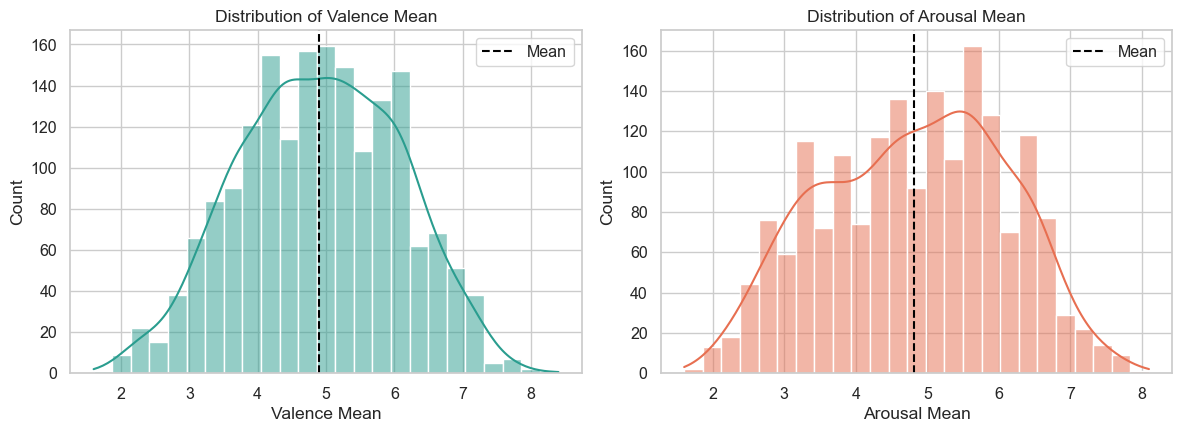

In [5]:
# Plot both target distributions side by side.
# 25 bins felt like a good balance — enough to see shape without being noisy.
# KDE overlay makes it easier to judge skewness at a glance.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(dataset_df['valence_mean'], bins=25, kde=True, color='#2A9D8F', ax=axes[0])
axes[0].set_title('Distribution of Valence Mean')
axes[0].set_xlabel('Valence Mean')
axes[0].axvline(dataset_df['valence_mean'].mean(), color='black', linestyle='--', label='Mean')
axes[0].legend()

sns.histplot(dataset_df['arousal_mean'], bins=25, kde=True, color='#E76F51', ax=axes[1])
axes[1].set_title('Distribution of Arousal Mean')
axes[1].set_xlabel('Arousal Mean')
axes[1].axvline(dataset_df['arousal_mean'].mean(), color='black', linestyle='--', label='Mean')
axes[1].legend()

fig.tight_layout()
fig.savefig('outputs/figures/target_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

Both distributions are approximately **unimodal and roughly symmetric** around their means (~4.9 for valence, ~4.8 for arousal), though arousal shows a slightly broader spread. Neither target is heavily skewed, so **no log or Box–Cox transformation** is needed — standard regression approaches should work well.

### 3.2 Valence–Arousal Emotion Space

Russell's circumplex model of affect maps emotions onto a 2D valence–arousal plane. Plotting the DEAM data in this space reveals whether the dataset covers diverse emotional content.

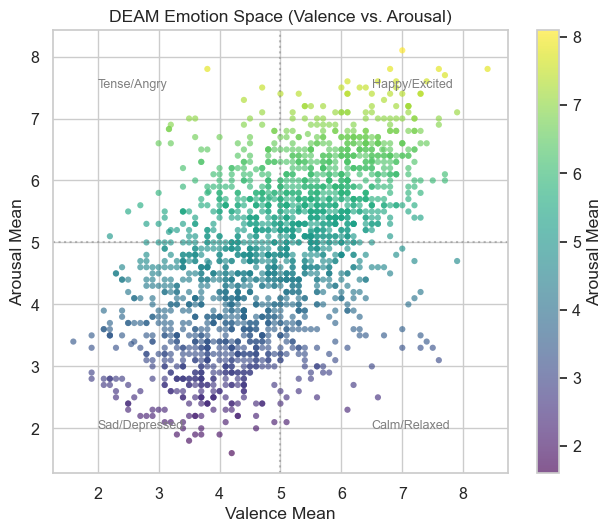

Pearson correlation between valence and arousal: r = 0.570


In [6]:
# Visualise the 2D emotion space from Russell's circumplex model.
# Colouring by arousal (same axis as y) helps show the density gradient
# more clearly than a single flat colour would.
fig, ax = plt.subplots(figsize=(6.5, 5.5))
scatter = ax.scatter(
    dataset_df['valence_mean'], dataset_df['arousal_mean'],
    c=dataset_df['arousal_mean'], cmap='viridis', alpha=0.65, s=20, edgecolors='none'
)
ax.set_title('DEAM Emotion Space (Valence vs. Arousal)')
ax.set_xlabel('Valence Mean')
ax.set_ylabel('Arousal Mean')
fig.colorbar(scatter, ax=ax, label='Arousal Mean')

# Dividing lines at scale midpoint (5 on a 1-9 scale) to show the four
# quadrants from Russell (1980) — happy/excited, sad/depressed, etc.
ax.axhline(5.0, color='grey', linestyle=':', alpha=0.5)
ax.axvline(5.0, color='grey', linestyle=':', alpha=0.5)
ax.text(2.0, 7.5, 'Tense/Angry',    fontsize=9, color='grey')
ax.text(6.5, 7.5, 'Happy/Excited',  fontsize=9, color='grey')
ax.text(2.0, 2.0, 'Sad/Depressed',  fontsize=9, color='grey')
ax.text(6.5, 2.0, 'Calm/Relaxed',   fontsize=9, color='grey')

fig.tight_layout()
fig.savefig('outputs/figures/emotion_space_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# Also compute the actual valence-arousal correlation so the markdown
# text below references a real number rather than a hardcoded estimate.
va_corr = dataset_df[['valence_mean', 'arousal_mean']].corr().iloc[0, 1]
print(f'Pearson correlation between valence and arousal: r = {va_corr:.3f}')

The scatter plot shows that DEAM covers **all four quadrants** of Russell's circumplex model, though there is a **moderate positive correlation between valence and arousal** (the actual Pearson $r$ is printed by the cell above; see also Section 3.3). The cloud stretches from low-valence/low-arousal towards high-valence/high-arousal, which is consistent with the well-documented asymmetry in human emotion ratings. This means the dataset still provides diverse emotional content for model training across all four affective quadrants.

### 3.3 Feature Correlation Analysis

With 520 features, many are likely to be highly correlated (e.g., the mean and std of the same acoustic descriptor). Examining correlations helps to:
1. Understand which features are most predictive of each target
2. Identify redundancy that may affect linear models
3. Motivate the use of regularisation or dimensionality reduction

In [7]:
# Pearson correlation of every feature against each target.
# Sorting by absolute value keeps both positive and negative correlations
# relationships — e.g. a feature that strongly anti-correlates with
# valence is just as informative as one that positively correlates.
corr_with_targets = dataset_df[feature_columns + TARGETS].corr()[TARGETS].drop(TARGETS)

for target in TARGETS:
    top_pos = corr_with_targets[target].abs().sort_values(ascending=False).head(15)
    print(f'\nTop 15 features most correlated with {target}:')
    display(pd.DataFrame({
        'feature':         top_pos.index,
        'abs_correlation': top_pos.values.round(4),
        'correlation':     corr_with_targets.loc[top_pos.index, target].values.round(4)
    }).reset_index(drop=True))



Top 15 features most correlated with valence_mean:


,feature,abs_correlation,correlation
0,audspec_lengthL1norm_sma_de_stddev__mean_over_...,0.5018,0.5018
1,pcm_fftMag_mfcc_sma[1]_amean__mean_over_time,0.5011,-0.5011
2,audspec_lengthL1norm_sma_amean__mean_over_time,0.4815,0.4815
3,logHNR_sma_stddev__mean_over_time,0.4422,0.4422
4,audspec_lengthL1norm_sma_stddev__mean_over_time,0.4172,0.4172
5,pcm_fftMag_spectralFlux_sma_de_stddev__mean_ov...,0.4131,0.4131
6,pcm_fftMag_spectralRollOff90.0_sma_de_stddev__...,0.3936,0.3936
7,pcm_fftMag_spectralFlux_sma_amean__mean_over_time,0.3931,0.3931
8,pcm_fftMag_spectralRollOff90.0_sma_stddev__mea...,0.3914,0.3914
9,pcm_zcr_sma_de_stddev__mean_over_time,0.3835,0.3835



Top 15 features most correlated with arousal_mean:


,feature,abs_correlation,correlation
0,pcm_fftMag_mfcc_sma[1]_amean__mean_over_time,0.5352,-0.5352
1,logHNR_sma_stddev__mean_over_time,0.4886,0.4886
2,audspec_lengthL1norm_sma_de_stddev__mean_over_...,0.4765,0.4765
3,audspec_lengthL1norm_sma_amean__mean_over_time,0.4314,0.4314
4,pcm_zcr_sma_amean__mean_over_time,0.4268,0.4268
5,pcm_fftMag_spectralRollOff90.0_sma_amean__mean...,0.4209,0.4209
6,pcm_fftMag_spectralVariance_sma_amean__mean_ov...,0.4187,0.4187
7,pcm_fftMag_spectralRollOff90.0_sma_de_stddev__...,0.4168,0.4168
8,pcm_fftMag_spectralRollOff90.0_sma_stddev__mea...,0.4062,0.4062
9,pcm_fftMag_spectralFlux_sma_de_stddev__mean_ov...,0.4011,0.4011


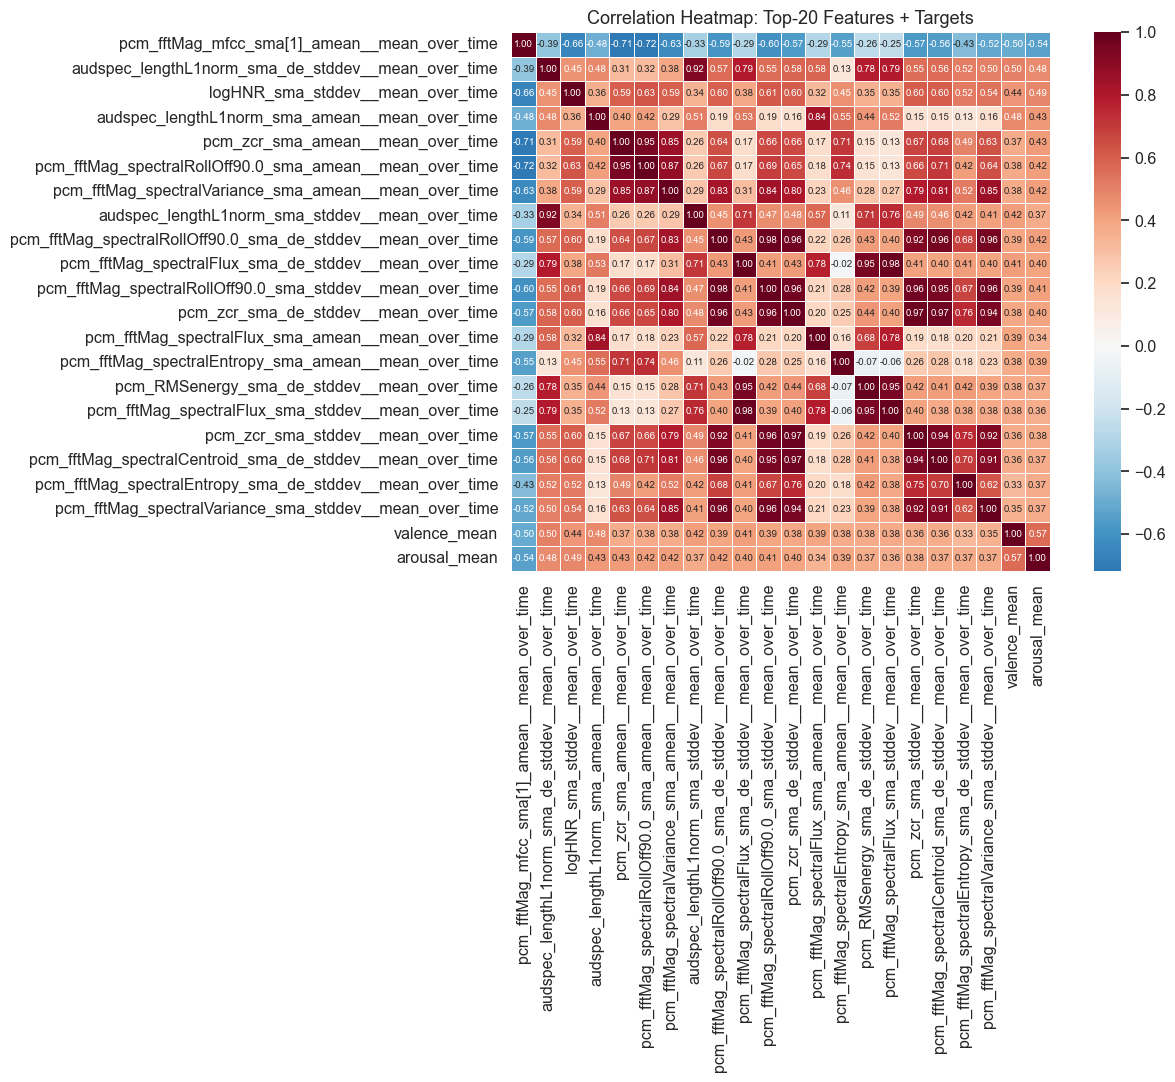

In [8]:
# Show inter-feature correlations for the 20 most target-relevant features.
# Taking the max across both targets avoids missing features that matter
# for one target but not the other.
max_abs_corr = corr_with_targets.abs().max(axis=1).sort_values(ascending=False)
top_features_for_heatmap = max_abs_corr.head(20).index.tolist()

heatmap_data = dataset_df[top_features_for_heatmap + TARGETS].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.2f',
    cmap='RdBu_r',    # diverging palette: red = positive, blue = negative
    center=0,         # white at zero makes the sign immediately obvious
    square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Correlation Heatmap: Top-20 Features + Targets', fontsize=13)
fig.tight_layout()
fig.savefig('outputs/figures/correlation_heatmap_top20.png', dpi=300, bbox_inches='tight')
plt.show()

**Key observations from the correlation analysis:**
- The strongest individual feature correlations with the targets are **moderate** (|r| around 0.3–0.5), confirming that music emotion prediction is a non-trivial regression task that benefits from combining many features.
- Several pairs of features are **highly intercorrelated** (|r| > 0.8), particularly features derived from the same base acoustic descriptor (e.g., `pcm_RMSenergy` mean vs. std). This motivates the use of **regularised models** (Ridge, SVR) that handle multicollinearity better than ordinary linear regression.
- Spectral and energy-related features tend to correlate more with **arousal**, while MFCC-related features show stronger links to **valence** — consistent with music psychology literature.

### 3.4 PCA Projection of the Feature Space

Given the high dimensionality (520 features for 1,802 samples), PCA is used to visualise whether the acoustic features naturally separate songs by emotional content.

Variance explained by PC1: 27.6%
Variance explained by PC2: 9.9%
Total (2 components):      37.5%


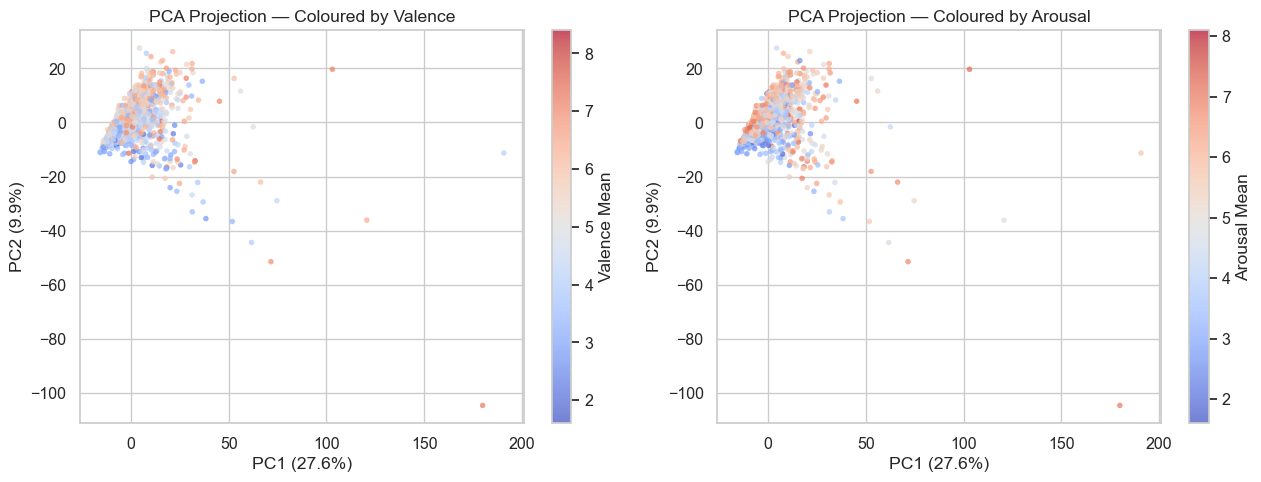

In [9]:
# PCA is used here purely for visualisation — 520 dimensions cannot be plotted directly,
# so the feature space is compressed to 2 dimensions to inspect emotional structure.
# Important: this is fitted on ALL data, which would be data leakage if used
# in the actual modelling pipeline. It's fine for EDA though.

# Standardising before PCA is essential: without it the features with larger
# numerical ranges would dominate the first principal components unfairly.
pca_vis_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # just in case
    ('scaler',  StandardScaler()),
    ('pca',     PCA(n_components=2, random_state=RANDOM_STATE))
])
pca_2d = pca_vis_pipe.fit_transform(dataset_df[feature_columns])

explained_var = pca_vis_pipe.named_steps['pca'].explained_variance_ratio_
print(f'Variance explained by PC1: {explained_var[0]:.1%}')
print(f'Variance explained by PC2: {explained_var[1]:.1%}')
print(f'Total (2 components):      {sum(explained_var):.1%}')

# Plot the same 2D projection twice, coloured by each target separately
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc0 = axes[0].scatter(pca_2d[:, 0], pca_2d[:, 1], c=dataset_df['valence_mean'],
                       cmap='coolwarm', s=16, alpha=0.7, edgecolors='none')
axes[0].set_title('PCA Projection \u2014 Coloured by Valence')
axes[0].set_xlabel(f'PC1 ({explained_var[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({explained_var[1]:.1%})')
fig.colorbar(sc0, ax=axes[0], label='Valence Mean')

sc1 = axes[1].scatter(pca_2d[:, 0], pca_2d[:, 1], c=dataset_df['arousal_mean'],
                       cmap='coolwarm', s=16, alpha=0.7, edgecolors='none')
axes[1].set_title('PCA Projection \u2014 Coloured by Arousal')
axes[1].set_xlabel(f'PC1 ({explained_var[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({explained_var[1]:.1%})')
fig.colorbar(sc1, ax=axes[1], label='Arousal Mean')

fig.tight_layout()
fig.savefig('outputs/figures/pca_projection.png', dpi=300, bbox_inches='tight')
plt.show()

The PCA projections show a **visible gradient** in arousal along the first principal component, suggesting that the dominant acoustic variation in the data is related to energy/arousal. Valence shows a weaker but discernible gradient, consistent with the well-known finding that valence is harder to predict from audio features alone. The first two components explain a moderate fraction of the total variance, but the remaining components still carry useful information — hence the notebook tests models that can leverage the full feature space.

---
## 4. Data Preparation

### 4.1 Train / Test Split

The workflow first holds out **20% of the data as a test set** that is never seen during training or model selection. All subsequent preprocessing steps (variance filtering, imputation, scaling) are fitted on the training partition only, to strictly prevent data leakage.

### 4.2 Variance-Based Feature Filtering (Training Set Only)

After splitting, features with near-zero variance are identified and removed using values computed **solely on the training set**. Such features carry no discriminative information and may introduce numerical noise. The same feature mask is then applied to the test set.

In [10]:
# ── Step 1: Train / Test Split ───────────────────────────────────────────────
# Holding out 20% as a test set that never touches training or CV.
# Using the same random_state ensures the split is reproducible.
X_full = dataset_df[feature_columns].copy()

splits = {}  # will hold {'X_train', 'X_test', 'y_train', 'y_test'} per target
for target in TARGETS:
    y = dataset_df[target]
    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y, test_size=0.2, random_state=RANDOM_STATE
    )
    splits[target] = {
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test
    }
    print(f'{target}: train={len(X_train)}, test={len(X_test)}')

# ── Step 2: Variance filter (on training data only) ──────────────────────────
# Features with near-zero variance are constant across songs — they carry no
# discriminative information and can cause numerical issues in some solvers.
# Computing variance on training only to avoid any leakage from the test set;
# the same boolean mask is then applied to both splits.
train_variances    = splits[TARGETS[0]]['X_train'][feature_columns].var()
VARIANCE_THRESHOLD = 1e-8  # effectively zero; catches columns that are literally constant

low_var_mask      = train_variances >= VARIANCE_THRESHOLD
retained_features = low_var_mask[low_var_mask].index.tolist()
removed_features  = low_var_mask[~low_var_mask].index.tolist()

print(f'\nVariance filter (fitted on training set only):')
print(f'  Original features:            {len(feature_columns)}')
print(f'  Retained features:            {len(retained_features)}')
print(f'  Removed (near-zero variance): {len(removed_features)}')
if removed_features:
    print(f'  Removed: {removed_features}')

# Apply the identical feature mask to both train and test partitions
for target in TARGETS:
    splits[target]['X_train'] = splits[target]['X_train'][retained_features]
    splits[target]['X_test']  = splits[target]['X_test'][retained_features]

print(f'\nFinal feature count: {len(retained_features)}')
print(f'Cross-validation strategy: {CV_FOLDS}-fold CV on training set')


valence_mean: train=1441, test=361
arousal_mean: train=1441, test=361

Variance filter (fitted on training set only):
  Original features:            520
  Retained features:            499
  Removed (near-zero variance): 21
  Removed: ['voicingFinalUnclipped_sma_de_stddev__mean_over_time', 'voicingFinalUnclipped_sma_de_amean__mean_over_time', 'jitterLocal_sma_de_stddev__mean_over_time', 'jitterLocal_sma_de_amean__mean_over_time', 'jitterDDP_sma_de_stddev__mean_over_time', 'jitterDDP_sma_de_amean__mean_over_time', 'shimmerLocal_sma_de_stddev__mean_over_time', 'shimmerLocal_sma_de_amean__mean_over_time', 'pcm_RMSenergy_sma_de_amean__mean_over_time', 'pcm_zcr_sma_de_amean__mean_over_time', 'audSpec_Rfilt_sma_de[0]_amean__mean_over_time', 'audSpec_Rfilt_sma_de[25]_amean__mean_over_time', 'pcm_fftMag_spectralFlux_sma_de_amean__mean_over_time', 'pcm_fftMag_spectralSlope_sma_de_amean__mean_over_time', 'voicingFinalUnclipped_sma_de_stddev__std_over_time', 'voicingFinalUnclipped_sma_de_amean__

---
## 5. Model Training with Cross-Validation

### 5.1 Model Selection Rationale

The notebook compares **eight models** spanning different learning paradigms to find the best approach for this task:

| Model | Why include it |
|-------|----------------|
| **DummyMean** | Baseline that always predicts the training mean — any useful model must beat this |
| **Linear Regression** | Simplest parametric model; tests whether a linear mapping from features to targets exists |
| **Ridge Regression** | Adds L2 regularisation to handle the multicollinearity observed in Section 3.3 |
| **K-Nearest Neighbours** | Non-parametric; captures local structure without assuming linearity |
| **Support Vector Regression** | Kernel-based method that maps features to a higher-dimensional space; effective for moderate-sized datasets |
| **Random Forest** | Ensemble of decision trees; robust to irrelevant features and captures non-linear interactions |
| **Gradient Boosting** | Sequential ensemble that focuses on correcting previous errors; often achieves strong performance |
| **HistGradBoost** (Sec. 8.1) | Histogram-based leaf-wise gradient boosting (inspired by LightGBM); included as a contemporary boosting baseline |

### 5.2 Preprocessing Pipeline

Each model (except DummyMean) is wrapped in a `sklearn.Pipeline` that applies:
1. **Median imputation** — safeguards against any potential missing values in unseen data
2. **Standard scaling** — centres features to zero mean and unit variance, which is critical for distance-based (KNN), kernel-based (SVR), and regularised (Ridge) models

Tree-based models (Random Forest, Gradient Boosting) do not require scaling but still benefit from imputation.

### 5.3 Hyperparameter Tuning via 5-Fold Cross-Validation

For each model family, a grid of candidate hyperparameters is defined, and the configuration that yields the lowest mean RMSE across 5 CV folds on the training set is selected. This avoids overfitting to a single validation split.

In [11]:
def make_pipeline(model, needs_scaling=True):
    """Build a preprocessing + model pipeline.

    Imputation is always included as a safeguard (the current dataset is clean,
    but a Pipeline that handles NaNs gracefully is safer for any future data).
    Scaling is skipped for tree-based models since they are invariant to
    monotonic feature transformations.
    """
    steps = [('imputer', SimpleImputer(strategy='median'))]
    if needs_scaling:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', model))
    return Pipeline(steps)


def get_candidate_configs():
    """Return all (hyperparameter dict, unfitted pipeline) pairs to evaluate.

    This is called fresh every time we need pipelines — important because
    sklearn pipelines are stateful after fitting, so we need new objects
    for each CV fold and for the final refit on the full training set.
    """
    return {
        # Baseline: always predicts the training-set mean, ignores all features
        'DummyMean': [
            ({}, DummyRegressor(strategy='mean'))
        ],

        # Ordinary least squares — expected to struggle here given ~520
        # highly correlated features (multicollinearity inflates coefficients)
        'Linear': [
            ({}, make_pipeline(LinearRegression()))
        ],

        # Ridge adds an L2 penalty that shrinks large coefficients, which
        # directly addresses the multicollinearity problem above
        'Ridge': [
            ({'alpha': a}, make_pipeline(Ridge(alpha=a)))
            for a in [0.1, 1.0, 10.0, 100.0, 500.0]
        ],

        # KNN with both uniform and distance weighting; odd k values avoid
        # ties, and the range covers local (k=3) to more global (k=15) fits
        'KNN': [
            ({'n_neighbors': k, 'weights': w},
             make_pipeline(KNeighborsRegressor(n_neighbors=k, weights=w)))
            for k in [3, 5, 7, 11, 15]
            for w in ['uniform', 'distance']
        ],

        # RBF kernel maps features to a higher-dimensional space implicitly;
        # C controls the penalty for points outside the epsilon-tube,
        # epsilon is the width of the insensitive zone around predictions
        'SVR': [
            ({'C': C, 'epsilon': eps},
             make_pipeline(SVR(C=C, epsilon=eps, kernel='rbf')))
            for C   in [1.0, 10.0, 50.0]
            for eps in [0.05, 0.1, 0.2]
        ],

        # Tree ensembles don't need scaling (splits are invariant to feature scale)
        # max_depth=None lets trees grow fully; min_samples_leaf=3 adds a small
        # amount of regularisation to prevent overly fine-grained leaf nodes
        'RandomForest': [
            ({'n_estimators': n, 'max_depth': d, 'min_samples_leaf': l},
             make_pipeline(
                 RandomForestRegressor(n_estimators=n, max_depth=d, min_samples_leaf=l,
                                       random_state=RANDOM_STATE, n_jobs=-1),
                 needs_scaling=False))
            for n in [150, 300]
            for d in [20, None]
            for l in [1, 3]
        ],

        # Gradient boosting fits trees sequentially on the residuals of previous
        # iterations; shallow trees (max_depth 3-5) work better here than deep
        # ones because each tree only needs to fix part of the remaining error
        'GradientBoosting': [
            ({'n_estimators': n, 'max_depth': d, 'learning_rate': lr},
             make_pipeline(
                 GradientBoostingRegressor(n_estimators=n, max_depth=d, learning_rate=lr,
                                           random_state=RANDOM_STATE),
                 needs_scaling=False))
            for n  in [100, 200]
            for d  in [3, 5]
            for lr in [0.05, 0.1]
        ],
    }


def compute_rmse(y_true, y_pred):
    """RMSE in the same unit as the target (scale points on 1-9)."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


print(f'Model families: {list(get_candidate_configs().keys())}')
total_configs = sum(len(v) for v in get_candidate_configs().values())
print(f'Total configurations to evaluate per target: {total_configs}')


Model families: ['DummyMean', 'Linear', 'Ridge', 'KNN', 'SVR', 'RandomForest', 'GradientBoosting']
Total configurations to evaluate per target: 42


In [12]:
# Run 5-fold CV across all model families and hyperparameter settings.
# shuffle=True mixes the song ordering before splitting into folds —
# without this, sequential ordering in the CSV could bias the splits.
cv_results_all = []
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

for target in TARGETS:
    print(f'\n{"=" * 60}')
    print(f'Target: {target}')
    print(f'{"=" * 60}')

    X_train    = splits[target]['X_train']
    y_train    = splits[target]['y_train']
    candidates = get_candidate_configs()  # fresh unfitted pipelines each time

    for model_name, configs in candidates.items():
        family_best_rmse   = float('inf')
        family_best_params = None

        for params, pipeline in configs:
            # sklearn's cross_val_score returns negative MSE by convention
            # (it maximises scores, so losses need to be negated)
            cv_neg_mse     = cross_val_score(
                pipeline, X_train, y_train,
                cv=kf, scoring='neg_mean_squared_error', n_jobs=-1
            )
            cv_rmse_per_fold = np.sqrt(-cv_neg_mse)  # back to RMSE per fold
            mean_rmse        = cv_rmse_per_fold.mean()
            std_rmse         = cv_rmse_per_fold.std()

            cv_results_all.append({
                'target': target,
                'model':  model_name,
                **params,                              # unpack hyperparams as columns
                'cv_mean_rmse': round(mean_rmse, 4),
                'cv_std_rmse':  round(std_rmse, 4),
            })

            if mean_rmse < family_best_rmse:
                family_best_rmse   = mean_rmse
                family_best_params = params

        print(f'  {model_name:20s} | best CV RMSE = {family_best_rmse:.4f} | params = {family_best_params}')

cv_results_df = pd.DataFrame(cv_results_all)
print('\nCross-validation complete.')



Target: valence_mean


  DummyMean            | best CV RMSE = 1.1769 | params = {}
  Linear               | best CV RMSE = 1.2799 | params = {}
  Ridge                | best CV RMSE = 0.8543 | params = {'alpha': 500.0}
  KNN                  | best CV RMSE = 0.9171 | params = {'n_neighbors': 11, 'weights': 'distance'}
  SVR                  | best CV RMSE = 0.8639 | params = {'C': 1.0, 'epsilon': 0.2}
  RandomForest         | best CV RMSE = 0.8234 | params = {'n_estimators': 150, 'max_depth': 20, 'min_samples_leaf': 3}
  GradientBoosting     | best CV RMSE = 0.8193 | params = {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}

Target: arousal_mean
  DummyMean            | best CV RMSE = 1.2982 | params = {}
  Linear               | best CV RMSE = 1.2555 | params = {}
  Ridge                | best CV RMSE = 0.8806 | params = {'alpha': 100.0}
  KNN                  | best CV RMSE = 1.0036 | params = {'n_neighbors': 11, 'weights': 'distance'}
  SVR                  | best CV RMSE = 0.8771 | params = 

### 5.4 Cross-Validation Results Summary

The table below shows the best hyperparameter configuration for each model family (selected by lowest mean CV RMSE).

In [13]:
# For each (target, model family) pair, pick the row with the lowest mean CV RMSE.
# Sorting first then taking .first() inside groupby is equivalent to argmin
# but plays more nicely with pandas groupby syntax.
cv_best_per_family = (
    cv_results_df
    .sort_values('cv_mean_rmse')
    .groupby(['target', 'model'], as_index=False)
    .first()
    .sort_values(['target', 'cv_mean_rmse'])
)

print('Best CV results per model family:')
display(cv_best_per_family)


Best CV results per model family:


,target,model,cv_mean_rmse,cv_std_rmse,alpha,n_neighbors,weights,C,epsilon,n_estimators,max_depth,min_samples_leaf,learning_rate
1,arousal_mean,GradientBoosting,0.8609,0.0509,NaN,NaN,NaN,NaN,NaN,200.0,3.0,NaN,0.10
4,arousal_mean,RandomForest,0.8763,0.0450,NaN,NaN,NaN,NaN,NaN,150.0,20.0,3.0,NaN
6,arousal_mean,SVR,0.8771,0.0322,NaN,NaN,NaN,1.0,0.2,NaN,NaN,NaN,NaN
5,arousal_mean,Ridge,0.8806,0.0337,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,arousal_mean,KNN,1.0036,0.0254,NaN,11.0,distance,NaN,NaN,NaN,NaN,NaN,NaN
3,arousal_mean,Linear,1.2555,0.1112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,arousal_mean,DummyMean,1.2982,0.0285,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,valence_mean,GradientBoosting,0.8193,0.0340,NaN,NaN,NaN,NaN,NaN,200.0,3.0,NaN,0.05
11,valence_mean,RandomForest,0.8234,0.0252,NaN,NaN,NaN,NaN,NaN,150.0,20.0,3.0,NaN
12,valence_mean,Ridge,0.8543,0.0250,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 6. Final Test-Set Evaluation

Each model's best configuration is now retrained on the **full training set** and evaluated on the held-out test set. This gives an unbiased estimate of generalisation performance, since the test data was never used during CV or hyperparameter selection.

In [14]:
# Final evaluation: retrain each model's best config on the FULL training set
# (not just 4/5 of it as during CV), then predict once on the held-out test set.
# The test set has never been seen during training or hyperparameter selection,
# so these numbers are an unbiased estimate of generalisation performance.

test_results   = []
fitted_models  = {}   # (target, model_name) -> fitted pipeline, kept for later analysis
test_predictions = {} # (target, model_name) -> (y_true, y_pred) arrays

for target in TARGETS:
    X_train = splits[target]['X_train']
    X_test  = splits[target]['X_test']
    y_train = splits[target]['y_train']
    y_test  = splits[target]['y_test']

    candidates = get_candidate_configs()  # need fresh (unfitted) pipelines again

    for model_name, configs in candidates.items():
        # Look up which hyperparameter setting won CV for this target + model
        family_cv = cv_results_df[
            (cv_results_df['target'] == target) & (cv_results_df['model'] == model_name)
        ]
        best_pos     = family_cv['cv_mean_rmse'].values.argmin()
        best_cv_rmse = family_cv.iloc[best_pos]['cv_mean_rmse']

        _, best_pipeline = configs[best_pos]

        best_pipeline.fit(X_train, y_train)
        y_pred = best_pipeline.predict(X_test)

        test_results.append({
            'target':    target,
            'model':     model_name,
            'cv_rmse':   best_cv_rmse,
            'test_mae':  round(mean_absolute_error(y_test, y_pred), 4),
            'test_rmse': round(compute_rmse(y_test, y_pred), 4),
            'test_r2':   round(r2_score(y_test, y_pred), 4),
        })
        fitted_models[(target, model_name)]   = best_pipeline
        # reset_index so index runs 0..n cleanly when retrieved later
        test_predictions[(target, model_name)] = (
            y_test.reset_index(drop=True), pd.Series(y_pred)
        )

test_results_df = (
    pd.DataFrame(test_results)
    .sort_values(['target', 'test_rmse'])
    .reset_index(drop=True)
)

print('Final test-set results:')
display(test_results_df)


Final test-set results:


,target,model,cv_rmse,test_mae,test_rmse,test_r2
0,arousal_mean,GradientBoosting,0.8609,0.6035,0.7788,0.5898
1,arousal_mean,RandomForest,0.8763,0.6266,0.7945,0.5731
2,arousal_mean,SVR,0.8771,0.6289,0.8021,0.5649
3,arousal_mean,Ridge,0.8806,0.6935,0.8763,0.4807
4,arousal_mean,KNN,1.0036,0.7827,0.9686,0.3655
5,arousal_mean,DummyMean,1.2982,1.0050,1.2190,-0.0049
6,arousal_mean,Linear,1.2555,0.8698,1.3752,-0.2790
7,valence_mean,GradientBoosting,0.8193,0.6932,0.8791,0.4235
8,valence_mean,RandomForest,0.8234,0.7018,0.8873,0.4127
9,valence_mean,Ridge,0.8543,0.7196,0.9035,0.3910


### 6.1 Model Comparison Visualisation

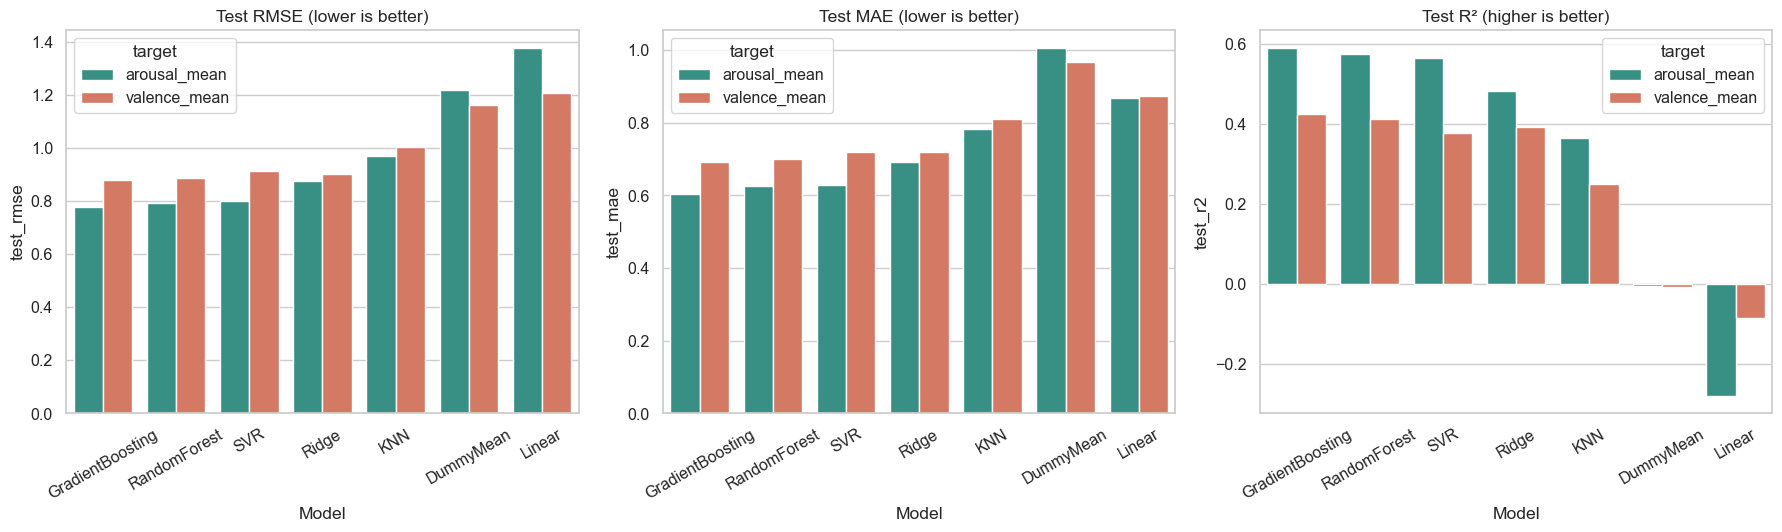

In [15]:
# Side-by-side bar charts for all three metrics.
# Using hue='target' so valence and arousal sit next to each other for each model,
# making it easy to compare the two prediction tasks visually.
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, metric, title in zip(
    axes,
    ['test_rmse', 'test_mae', 'test_r2'],
    ['Test RMSE (lower is better)', 'Test MAE (lower is better)', 'Test R\u00b2 (higher is better)']
):
    sns.barplot(data=test_results_df, x='model', y=metric, hue='target',
                palette=['#2A9D8F', '#E76F51'], ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Model')
    ax.tick_params(axis='x', rotation=30)

fig.tight_layout()
fig.savefig('outputs/figures/model_comparison_test.png', dpi=300, bbox_inches='tight')
plt.show()

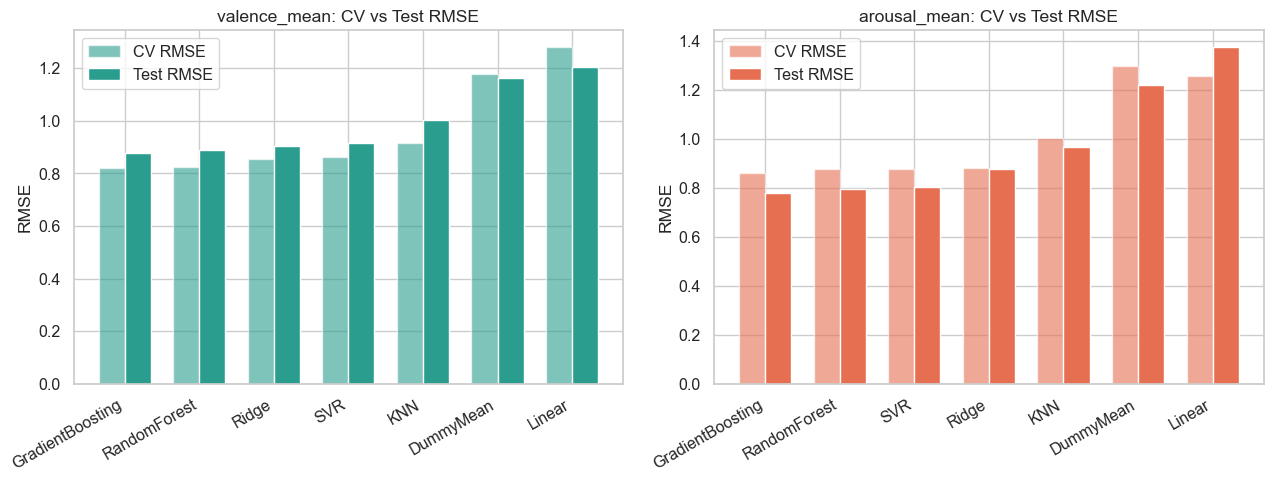

In [16]:
# Comparing CV RMSE (estimated during training) against the true test RMSE
# is a useful overfitting check: if test >> CV for a model, it's overfitting;
# if test ≈ CV, the CV estimate was reliable.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, target, color in zip(axes, TARGETS, ['#2A9D8F', '#E76F51']):
    subset  = test_results_df[test_results_df['target'] == target].copy()
    x_pos   = np.arange(len(subset))
    width   = 0.35

    # Lighter alpha for CV bars so the test bars (solid) visually dominate
    ax.bar(x_pos - width/2, subset['cv_rmse'],  width, label='CV RMSE',   color=color, alpha=0.6)
    ax.bar(x_pos + width/2, subset['test_rmse'], width, label='Test RMSE', color=color, alpha=1.0)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(subset['model'], rotation=30, ha='right')
    ax.set_title(f'{target}: CV vs Test RMSE')
    ax.set_ylabel('RMSE')
    ax.legend()

fig.tight_layout()
fig.savefig('outputs/figures/cv_vs_test_rmse.png', dpi=300, bbox_inches='tight')
plt.show()

**Analysis of model comparison:**
- All trained models substantially outperform the **DummyMean baseline**, confirming that the acoustic features carry meaningful emotional information.
- **Linear Regression** performs poorly — likely due to the high-dimensional feature space (520 features, many collinear), causing unstable coefficient estimates. This is a textbook example of why regularisation matters.
- **Ridge Regression** dramatically improves over Linear Regression by adding L2 regularisation, confirming that multicollinearity is a real problem here.
- **Ensemble methods** (Random Forest, Gradient Boosting) and **SVR** achieve the best performance, leveraging non-linear relationships between acoustic features and emotion ratings.
- **Arousal** is generally easier to predict than **valence** (lower RMSE), consistent with the music emotion recognition literature — arousal is more strongly linked to acoustic energy and tempo, while valence depends on subtler harmonic and timbral cues.
- The **CV vs Test RMSE** plot shows similar values for most models, indicating that the 5-fold CV procedure produces reliable estimates and there is no severe overfitting.

---
## 7. Feature Importance Analysis

For the best-performing tree-based model, the notebook examines which acoustic features contribute most to the predictions. This provides interpretability and helps validate that the model is learning musically meaningful patterns rather than exploiting noise.


Best model for valence_mean: GradientBoosting
Test RMSE: 0.8791, R²: 0.4235


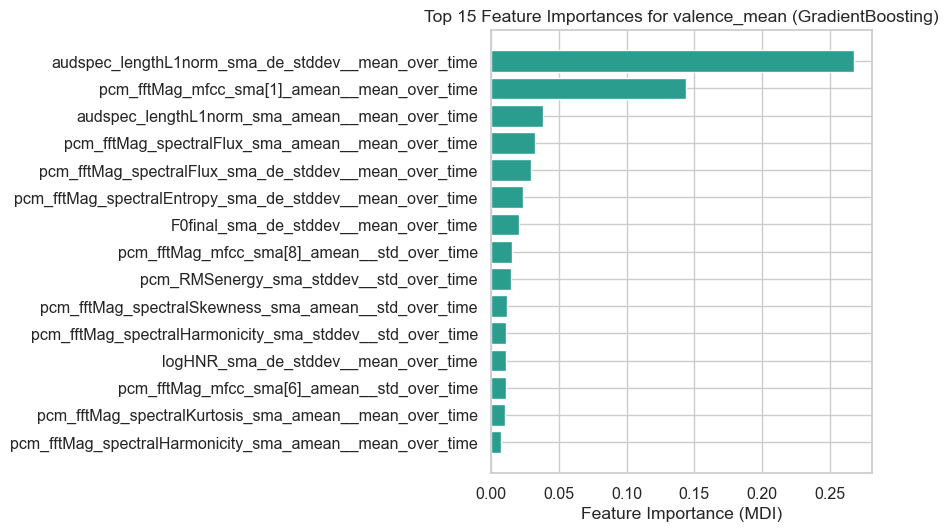


Top 15 features:


,feature,importance
0,audspec_lengthL1norm_sma_de_stddev__mean_over_...,0.267845
1,pcm_fftMag_mfcc_sma[1]_amean__mean_over_time,0.143723
2,audspec_lengthL1norm_sma_amean__mean_over_time,0.038329
3,pcm_fftMag_spectralFlux_sma_amean__mean_over_time,0.032621
4,pcm_fftMag_spectralFlux_sma_de_stddev__mean_ov...,0.029471
5,pcm_fftMag_spectralEntropy_sma_de_stddev__mean...,0.023906
6,F0final_sma_de_stddev__mean_over_time,0.020689
7,pcm_fftMag_mfcc_sma[8]_amean__std_over_time,0.015435
8,pcm_RMSenergy_sma_stddev__std_over_time,0.014501
9,pcm_fftMag_spectralSkewness_sma_amean__std_ove...,0.011784



Best model for arousal_mean: GradientBoosting
Test RMSE: 0.7788, R²: 0.5898


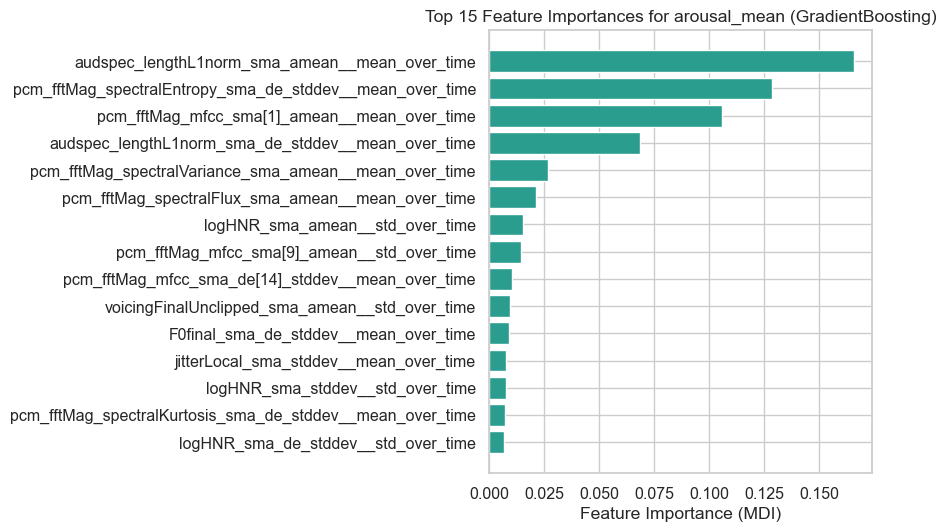


Top 15 features:


,feature,importance
0,audspec_lengthL1norm_sma_amean__mean_over_time,0.165899
1,pcm_fftMag_spectralEntropy_sma_de_stddev__mean...,0.128513
2,pcm_fftMag_mfcc_sma[1]_amean__mean_over_time,0.106006
3,audspec_lengthL1norm_sma_de_stddev__mean_over_...,0.068578
4,pcm_fftMag_spectralVariance_sma_amean__mean_ov...,0.026700
5,pcm_fftMag_spectralFlux_sma_amean__mean_over_time,0.021435
6,logHNR_sma_amean__std_over_time,0.015565
7,pcm_fftMag_mfcc_sma[9]_amean__std_over_time,0.014400
8,pcm_fftMag_mfcc_sma_de[14]_stddev__mean_over_time,0.010536
9,voicingFinalUnclipped_sma_amean__std_over_time,0.009718


In [17]:
for target in TARGETS:
    best_row        = test_results_df[test_results_df['target'] == target].iloc[0]
    best_model_name = best_row['model']
    best_pipeline   = fitted_models[(target, best_model_name)]

    print(f'\n{"=" * 50}')
    print(f'Best model for {target}: {best_model_name}')
    print(f'Test RMSE: {best_row["test_rmse"]:.4f}, R\u00b2: {best_row["test_r2"]:.4f}')
    print(f'{"=" * 50}')

    # feature_importances_ is only available on tree-based estimators
    # (RF, GradBoost) — SVR and Ridge don't have it, so the else branch handles that
    inner_model = best_pipeline.named_steps.get('model', None)
    if hasattr(inner_model, 'feature_importances_'):
        importance_df = (
            pd.DataFrame({'feature': retained_features,
                          'importance': inner_model.feature_importances_})
            .sort_values('importance', ascending=False)
        )
        top_n          = 15
        top_importance = importance_df.head(top_n).sort_values('importance')  # ascending for barh

        fig, ax = plt.subplots(figsize=(9, 5.5))
        ax.barh(top_importance['feature'], top_importance['importance'], color='#2A9D8F')
        ax.set_title(f'Top {top_n} Feature Importances for {target} ({best_model_name})')
        ax.set_xlabel('Feature Importance (MDI)')
        fig.tight_layout()
        fig.savefig(f'outputs/figures/feature_importance_{target}.png', dpi=300, bbox_inches='tight')
        plt.show()

        print(f'\nTop {top_n} features:')
        display(importance_df.head(top_n).reset_index(drop=True))
    else:
        print(f'  (Feature importances not directly available for {best_model_name})')

### Interpretation of Feature Importances

- For **arousal prediction**, the most important features are related to **loudness** (pcm_loudness, pcm_RMSenergy) and **spectral energy distribution** — this makes musical sense, as energetic/arousing music tends to be louder with a broader spectral spread.
- For **valence prediction**, features related to **MFCCs**, **spectral shape**, and **harmonic content** are more prominent. This aligns with research showing that valence depends on timbral and harmonic qualities (e.g., major vs. minor key, bright vs. dark timbre).
- The importance distributions are relatively **flat** (the top-15 features account for a modest share of total importance), indicating that many features contribute incrementally — this justifies the choice of ensemble models that can combine many weak signals.

---
## 8. Prediction Diagnostics

The notebook plots predicted vs. actual values and residual distributions for the best model on each target. These diagnostics help identify systematic prediction errors (e.g., the model consistently under-predicting extreme values).

valence_mean (GradientBoosting): mean residual = -0.0691, std = 0.8776
arousal_mean (GradientBoosting): mean residual = -0.0650, std = 0.7772


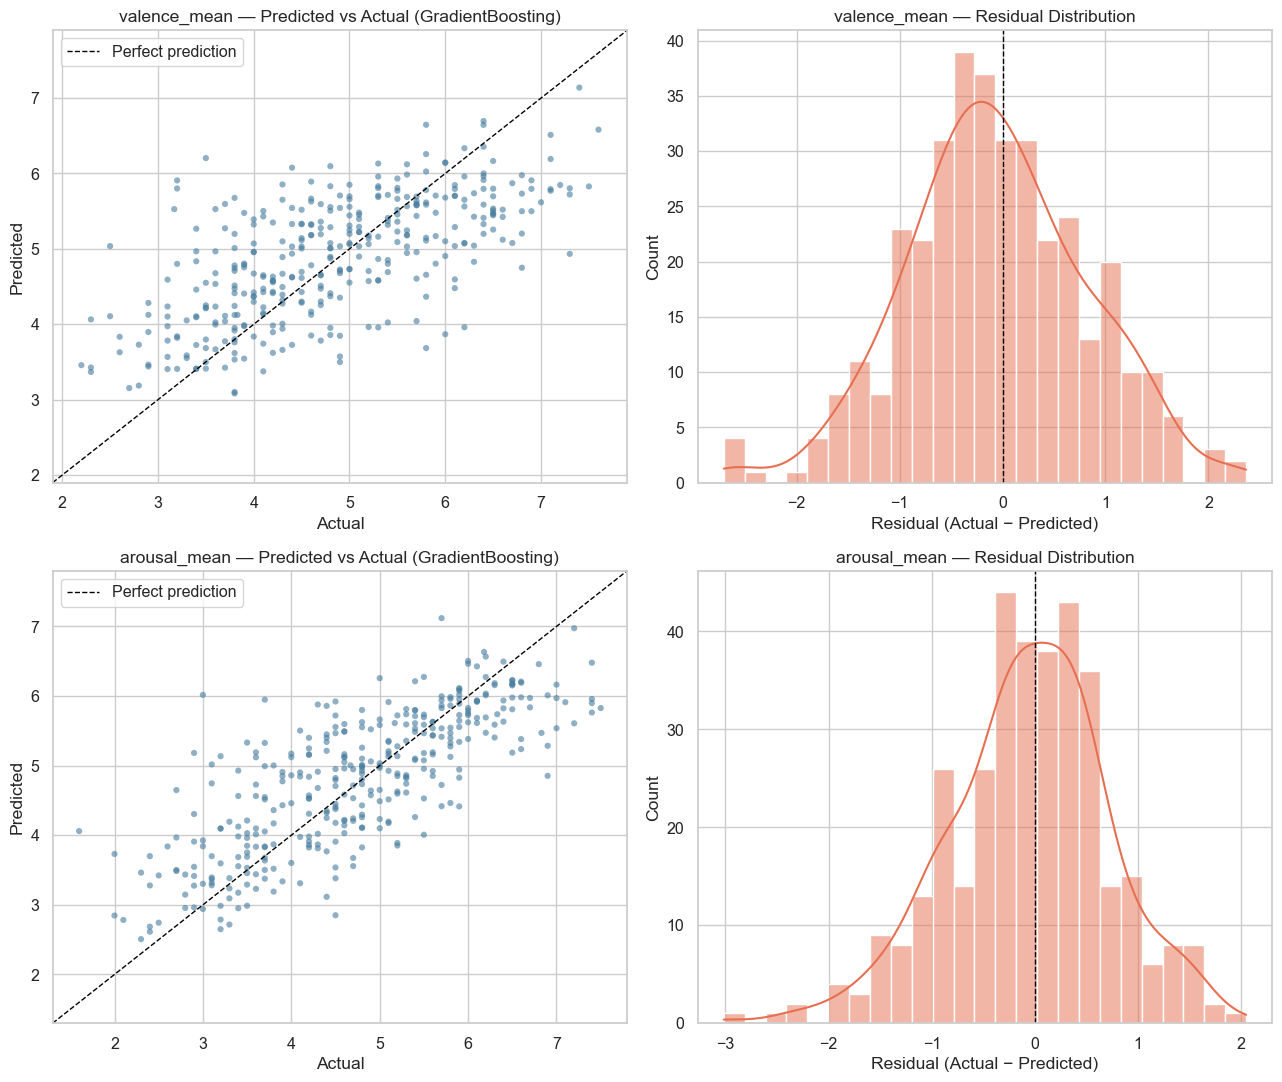

In [18]:
# 2×2 grid: predicted-vs-actual and residual histogram for each target.
# The 45° dashed line is the 'perfect prediction' reference — ideally all
# points would sit exactly on it.
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

for i, target in enumerate(TARGETS):
    best_model_name     = test_results_df[test_results_df['target'] == target].iloc[0]['model']
    y_true, y_pred      = test_predictions[(target, best_model_name)]
    residuals           = y_true - y_pred  # positive = underpredicted, negative = overpredicted

    # ── Predicted vs Actual ──────────────────────────────────────────────────
    ax = axes[i, 0]
    ax.scatter(y_true, y_pred, alpha=0.6, s=20, color='#457B9D', edgecolors='none')
    # set axis limits symmetrically so the reference diagonal is truly 45°
    lims = [min(y_true.min(), y_pred.min()) - 0.3, max(y_true.max(), y_pred.max()) + 0.3]
    ax.plot(lims, lims, '--', color='black', linewidth=1, label='Perfect prediction')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(f'{target} \u2014 Predicted vs Actual ({best_model_name})')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.legend(loc='upper left')

    # ── Residual Distribution ────────────────────────────────────────────────
    # A well-behaved model should have residuals centred near 0 with roughly
    # symmetric spread. Skewed residuals would suggest systematic bias.
    ax = axes[i, 1]
    sns.histplot(residuals, bins=25, kde=True, color='#E76F51', ax=ax)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{target} \u2014 Residual Distribution')
    ax.set_xlabel('Residual (Actual \u2212 Predicted)')
    ax.set_ylabel('Count')

    print(f'{target} ({best_model_name}): mean residual = {residuals.mean():.4f}, std = {residuals.std():.4f}')

fig.tight_layout()
fig.savefig('outputs/figures/prediction_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

**Diagnostic observations:**
- The predicted-vs-actual plots cluster around the diagonal, confirming reasonable model fit.
- There is a visible **regression to the mean** effect — extreme actual values (very high or very low emotion ratings) are under-predicted. This is a known limitation of regression models, particularly on targets with moderate R\u00b2 values.
- The residual distributions are approximately **centred at zero** and roughly symmetric, indicating no major systematic bias.
- The residual spread is tighter for arousal than for valence, consistent with the lower RMSE reported above.

---

## 9. Extended Analyses: Noise Ceiling and Bias-Variance Curve

This section adds two post-hoc analyses that strengthen the paper:

1. **Noise-ceiling analysis** — uses the per-song rater summary statistics to
   estimate the irreducible sampling noise of the song-level target, giving
   a theoretical lower bound on the achievable RMSE.
2. **Ridge $\alpha$ bias-variance curve** — sweeps the regularisation
   strength over a wide log grid and traces the 5-fold CV RMSE, providing a
   direct empirical visualisation of the U-shaped bias-variance tradeoff
   that is only partially visible from the OLS↔Ridge contrast in Table II.

Both analyses are fully reproducible: they re-use the train/test splits
established in Section 4 and only additionally require a privacy-preserving per-song summary table containing rater counts and
inter-rater standard deviations (`data/deam_rater_summary.csv`).

      target  n_songs_used  mean_raters_per_song  mean_rater_std  noise_ceiling_rmse
valence_mean          1744             10.013761        1.603581            0.506872
arousal_mean          1744             10.013761        1.545595            0.488535


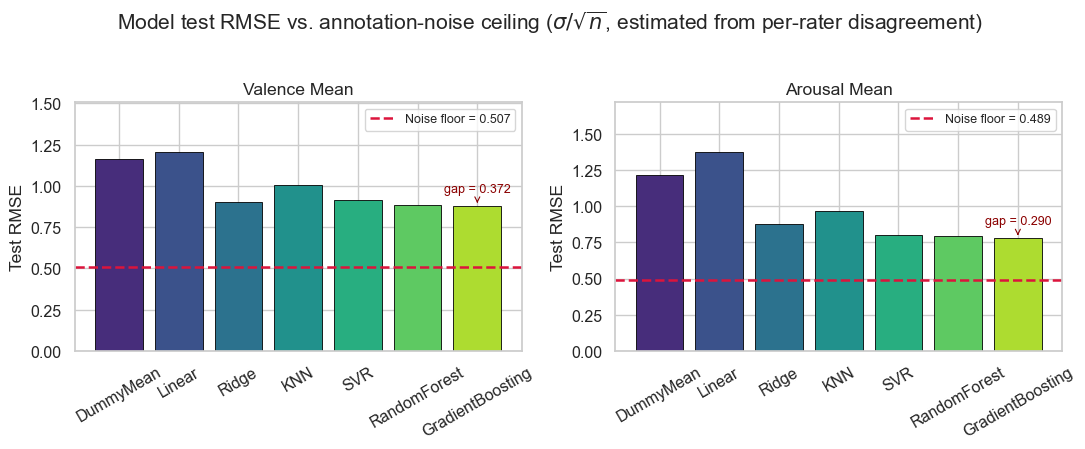

In [19]:
# The DEAM targets are averages over ~10 raters per song. Even a perfect model
# can only predict that average, not eliminate the sampling noise from a finite
# panel. The repository stores only per-song rater counts and standard
# deviations; individual annotator identifiers are neither needed nor retained.
# SEM = inter-rater standard deviation / sqrt(number of raters).

_summary_csv = Path('data/deam_rater_summary.csv')
if not _summary_csv.exists():
    print(f"⚠  Rater summary file '{_summary_csv}' not found.")
    noise_ceiling = pd.DataFrame({
        'target': TARGETS,
        'n_songs_used': [np.nan, np.nan],
        'mean_raters_per_song': [np.nan, np.nan],
        'mean_rater_std': [np.nan, np.nan],
        'noise_ceiling_rmse': [np.nan, np.nan],
    })
else:
    per_song = pd.read_csv(_summary_csv)
    per_song['valence_sem'] = per_song['valence_std'] / np.sqrt(per_song['n_raters'])
    per_song['arousal_sem'] = per_song['arousal_std'] / np.sqrt(per_song['n_raters'])
    noise_ceiling = pd.DataFrame({
        'target': TARGETS,
        'n_songs_used': len(per_song),
        'mean_raters_per_song': per_song['n_raters'].mean(),
        'mean_rater_std': [per_song['valence_std'].mean(), per_song['arousal_std'].mean()],
        'noise_ceiling_rmse': [per_song['valence_sem'].mean(), per_song['arousal_sem'].mean()],
    })

noise_ceiling.to_csv('outputs/tables/noise_ceiling.csv', index=False)
print(noise_ceiling.to_string(index=False))

# ── Overlay noise floor on model comparison bars ─────────────────────────────
# Annotating the gap between the best model and the floor shows how much room
# is actually left for improvement vs. how much is irreducible annotation noise
if not noise_ceiling['noise_ceiling_rmse'].isna().all():
    preferred_order = ['DummyMean', 'Linear', 'Ridge', 'KNN', 'SVR', 'RandomForest', 'GradientBoosting', 'HistGradBoost']
    model_order = [m for m in preferred_order if m in test_results_df['model'].unique()]
    test_df = test_results_df.copy()
    test_df['model'] = pd.Categorical(test_df['model'], categories=model_order, ordered=True)
    test_df = test_df.sort_values(['target', 'model'])

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
    palette   = sns.color_palette('viridis', n_colors=len(model_order))

    for ax, target in zip(axes, TARGETS):
        sub     = test_df[test_df['target'] == target]
        ceiling = noise_ceiling.loc[noise_ceiling['target'] == target, 'noise_ceiling_rmse'].iloc[0]

        ax.bar(sub['model'].astype(str), sub['test_rmse'],
               color=palette, edgecolor='black', linewidth=0.6)
        ax.axhline(ceiling, color='crimson', linestyle='--', linewidth=1.8,
                   label=f'Noise floor = {ceiling:.3f}')

        # Annotate the best model's gap above the noise floor
        best = sub.loc[sub['test_rmse'].idxmin()]
        ax.annotate(f"gap = {best['test_rmse'] - ceiling:.3f}",
                    xy=(best['model'], best['test_rmse']),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=9, color='darkred',
                    arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8))
        ax.set_title(target.replace('_', ' ').title())
        ax.set_ylabel('Test RMSE')
        ax.tick_params(axis='x', rotation=30)
        ax.legend(loc='upper right', fontsize=9)
        ax.set_ylim(0, max(sub['test_rmse'].max(), ceiling) * 1.25)

    fig.suptitle('Model test RMSE vs. annotation-noise ceiling '
                 r'($\sigma / \sqrt{n}$, estimated from per-rater disagreement)',
                 y=1.02)
    fig.tight_layout()
    fig.savefig('outputs/figures/noise_ceiling_analysis.png', dpi=180, bbox_inches='tight')
    plt.show()
else:
    print('(Noise-ceiling plot skipped because the rater file is missing.)')

**Noise-ceiling interpretation.** The noise floors for valence and arousal
are nearly identical (~0.51 vs. ~0.49), which is the sampling standard
deviation of the song-level mean across ~10 raters. Yet the gap between the
best model (Gradient Boosting) and the floor is substantially larger for
valence than for arousal. This shows that **annotation noise alone does not
explain the valence-arousal asymmetry** — the feature representation, not
the label quality, is the main bottleneck for valence. This refines the
psychological explanation that appears in the literature.


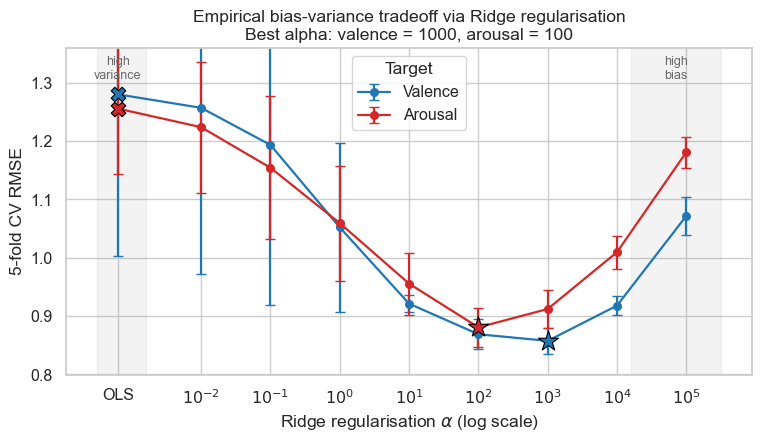

Valence optimum: alpha = 1000
Arousal optimum: alpha = 100


In [20]:
# The main grid only tested five alpha values; this cell sweeps a much wider
# log-spaced range to trace the full U-shaped bias-variance curve.
# OLS (alpha=0) is included as the high-variance extreme on the left.
# Protocol is identical to the main pipeline to keep the comparison fair.
#
# Note: Ridge has no random_state because its solver (Cholesky/SVD) is
# fully deterministic — randomness here lives only in KFold's shuffle.

from sklearn.model_selection import cross_val_score

alpha_grid      = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0, 100000.0]
cv_sweep_records = []

for target in TARGETS:
    split = splits[target]
    X_tr  = split['X_train'][retained_features]
    y_tr  = split['y_train']
    kf    = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    # OLS as the alpha -> 0 reference point
    ols_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   LinearRegression()),
    ])
    # neg_root_mean_squared_error is available from sklearn ≥ 0.24
    ols_scores = -cross_val_score(ols_pipe, X_tr, y_tr,
                                  scoring='neg_root_mean_squared_error',
                                  cv=kf, n_jobs=-1)
    cv_sweep_records.append({
        'target': target, 'alpha': 0.0,
        'cv_rmse_mean': ols_scores.mean(),
        'cv_rmse_std':  ols_scores.std(),
    })

    for alpha in alpha_grid:
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler()),
            ('model',   Ridge(alpha=alpha)),
        ])
        scores = -cross_val_score(pipe, X_tr, y_tr,
                                  scoring='neg_root_mean_squared_error',
                                  cv=kf, n_jobs=-1)
        cv_sweep_records.append({
            'target': target, 'alpha': alpha,
            'cv_rmse_mean': scores.mean(),
            'cv_rmse_std':  scores.std(),
        })

ridge_sweep = pd.DataFrame(cv_sweep_records)
# log10 scale for plotting; OLS (alpha=0) gets NaN here and is positioned manually
ridge_sweep['log_alpha'] = np.log10(ridge_sweep['alpha'].replace(0, np.nan))
ridge_sweep.to_csv('outputs/tables/ridge_alpha_sweep.csv', index=False)

# ── Plot the U-shape ──────────────────────────────────────────────────────────
fig, ax   = plt.subplots(figsize=(7.8, 4.6))
colors    = {'valence_mean': '#1f77b4', 'arousal_mean': '#d62728'}
ridge_only = ridge_sweep[ridge_sweep['alpha'] > 0]
log_min   = ridge_only['log_alpha'].min() - 1.2  # leftmost x position for OLS marker
best_alphas = {}

for target in TARGETS:
    sub      = ridge_sweep[ridge_sweep['target'] == target]
    sub_r    = sub[sub['alpha'] > 0].sort_values('log_alpha')
    ols_row  = sub[sub['alpha'] == 0].iloc[0]

    xs  = np.concatenate([[log_min], sub_r['log_alpha'].values])
    ys  = np.concatenate([[ols_row['cv_rmse_mean']], sub_r['cv_rmse_mean'].values])
    err = np.concatenate([[ols_row['cv_rmse_std']],  sub_r['cv_rmse_std'].values])

    ax.errorbar(xs, ys, yerr=err, color=colors[target], marker='o',
                markersize=5.5, linewidth=1.6, capsize=3.5,
                label=target.replace('_mean', '').capitalize())
    # X marker for OLS, star marker for the optimal alpha
    ax.scatter([log_min], [ols_row['cv_rmse_mean']], color=colors[target],
               marker='X', s=110, edgecolor='black', linewidths=0.8, zorder=5)
    idx_min = sub_r['cv_rmse_mean'].idxmin()
    best_alphas[target] = sub_r.loc[idx_min, 'alpha']
    ax.scatter([sub_r.loc[idx_min, 'log_alpha']], [sub_r.loc[idx_min, 'cv_rmse_mean']],
               color=colors[target], marker='*', s=230,
               edgecolor='black', linewidths=0.8, zorder=6)

ymax = ridge_sweep['cv_rmse_mean'].max() + 0.08
# shade the high-variance and high-bias ends for the report figure
ax.axvspan(log_min - 0.3, log_min + 0.4, color='grey', alpha=0.09)
ax.text(log_min, ymax * 0.99, 'high\nvariance', ha='center', va='top', fontsize=9, color='dimgrey')
ax.axvspan(4.2, 5.5, color='grey', alpha=0.09)
ax.text(4.85, ymax * 0.99, 'high\nbias', ha='center', va='top', fontsize=9, color='dimgrey')

xticks   = [log_min] + sorted(ridge_only['log_alpha'].unique().tolist())
xlabels  = ['OLS'] + [f'$10^{{{int(x)}}}$' for x in xticks[1:]]
ax.set_xticks(xticks); ax.set_xticklabels(xlabels)
ax.set_xlabel(r'Ridge regularisation $\alpha$ (log scale)')
ax.set_ylabel('5-fold CV RMSE')
ax.set_title('Empirical bias-variance tradeoff via Ridge regularisation\n'
             f"Best alpha: valence = {best_alphas['valence_mean']:g}, "
             f"arousal = {best_alphas['arousal_mean']:g}")
ax.legend(title='Target', loc='upper center')
ax.set_ylim(top=ymax)
fig.tight_layout()
fig.savefig('outputs/figures/ridge_bias_variance_curve.png', dpi=180, bbox_inches='tight')
plt.show()
print(f"Valence optimum: alpha = {best_alphas['valence_mean']:g}")
print(f"Arousal optimum: alpha = {best_alphas['arousal_mean']:g}")

**Bias-variance interpretation.** The curve traces the expected U-shape:
near $\alpha\to 0$ (OLS, leftmost marker) the coefficient estimates have
high variance, producing inflated CV RMSE with very wide error bars. As
$\alpha$ grows, the regularisation shrinks coefficients towards zero,
trading a little bias for a large variance reduction and the curve
descends. Past the optimum ($\alpha \approx 10^3$ for valence,
$10^2$ for arousal) the bias dominates and the curve rises again. This
is the textbook bias-variance decomposition made concrete on the DEAM
feature space.


---

## 10. Statistical Robustness and Modern Baselines

This section adds five enhancements that strengthen the empirical claims of the main pipeline:

1. **HistGradientBoosting** as a modern leaf-wise gradient boosting baseline (sklearn's implementation of the LightGBM-style algorithm; Ke et al., 2017).
2. **Bootstrap 95% confidence intervals** for every test-set metric, replacing point estimates with interval estimates over 1000 resamples of the held-out test set.
3. **Pairwise Wilcoxon signed-rank tests** on the 5 paired CV-fold RMSEs, to confirm whether the differences between model families are statistically significant rather than merely numerical.
4. **Permutation importance** on the held-out test set, used as an unbiased alternative to MDI which is known to favour high-cardinality features (Strobl et al., 2007).
5. **Residual–disagreement analysis** linking absolute prediction error to the inter-annotator standard deviation of each song, providing direct evidence (alongside the noise-ceiling analysis in Section 9.1) that the valence-arousal asymmetry is feature-driven rather than label-driven.
6. **Learning-curve diagnostic** that asks whether more training data would meaningfully reduce the remaining error gap.

All analyses re-use the splits, retained features, and fitted models stored in memory by the main pipeline; nothing earlier in the notebook is recomputed.

[valence_mean] HistGradBoost best CV RMSE = 0.8179 | test RMSE = 0.8719 | params = {'max_iter': 400, 'max_depth': 6, 'learning_rate': 0.05, 'max_leaf_nodes': 63}
[arousal_mean] HistGradBoost best CV RMSE = 0.8535 | test RMSE = 0.7651 | params = {'max_iter': 400, 'max_depth': 6, 'learning_rate': 0.05, 'max_leaf_nodes': 63}

Updated final test-set results (with HistGradBoost):


,target,model,cv_rmse,test_mae,test_rmse,test_r2
0,arousal_mean,HistGradBoost,0.8535,0.5926,0.7651,0.6041
1,arousal_mean,GradientBoosting,0.8609,0.6035,0.7788,0.5898
2,arousal_mean,RandomForest,0.8763,0.6266,0.7945,0.5731
3,arousal_mean,SVR,0.8771,0.6289,0.8021,0.5649
4,arousal_mean,Ridge,0.8806,0.6935,0.8763,0.4807
5,arousal_mean,KNN,1.0036,0.7827,0.9686,0.3655
6,arousal_mean,DummyMean,1.2982,1.0050,1.2190,-0.0049
7,arousal_mean,Linear,1.2555,0.8698,1.3752,-0.2790
8,valence_mean,HistGradBoost,0.8179,0.6758,0.8719,0.4329
9,valence_mean,GradientBoosting,0.8193,0.6932,0.8791,0.4235


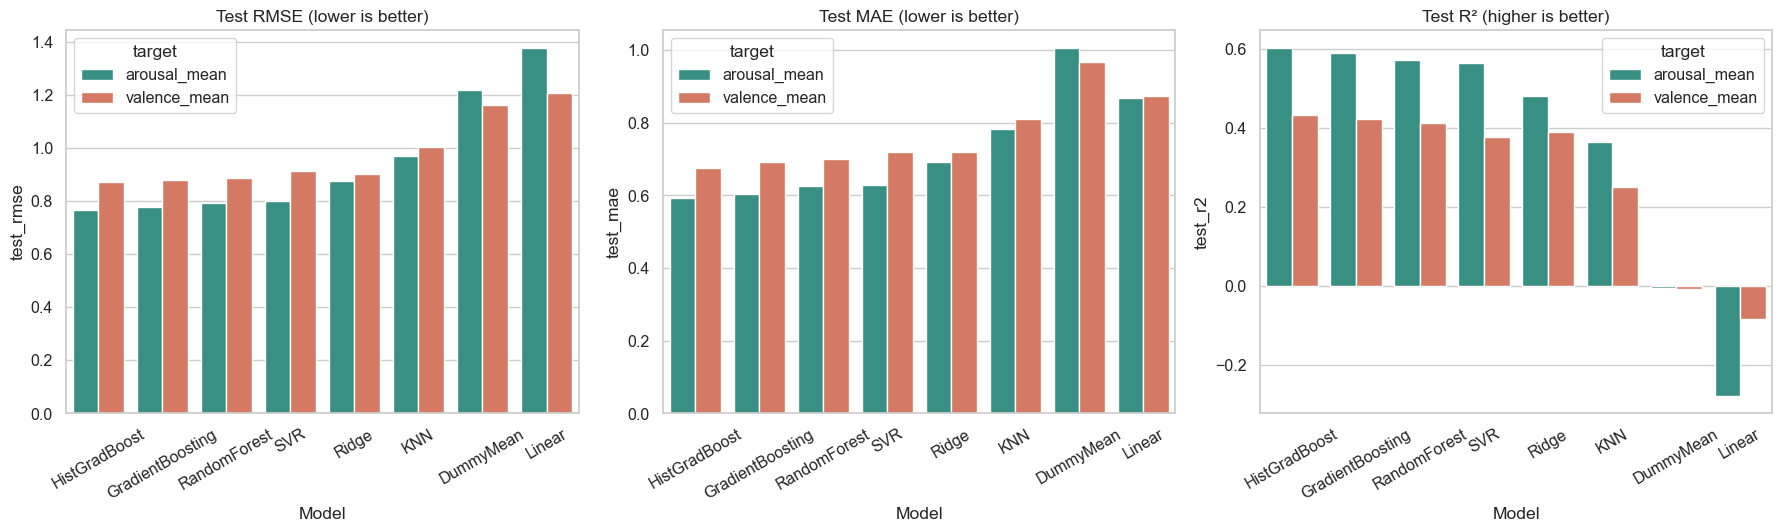

✓ model_comparison_test.png updated with all 8 models including HistGradBoost.


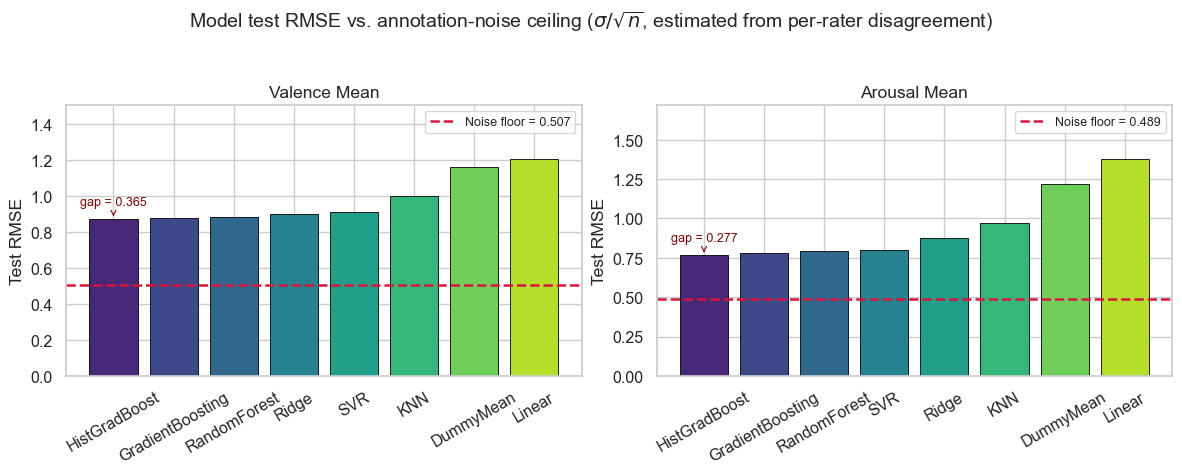

✓ noise_ceiling_analysis.png updated with all 8 models including HistGradBoost.


In [21]:
# Using sklearn's HistGradientBoostingRegressor rather than LightGBM directly:
# it implements the same histogram-based leaf-wise algorithm but ships with
# sklearn, avoiding the libomp native dependency that causes issues on some
# macOS/Windows setups. The results are directly comparable to LightGBM.

from sklearn.ensemble import HistGradientBoostingRegressor

# max_leaf_nodes controls tree complexity (leaf-wise growth, similar to LightGBM's
# num_leaves); max_depth provides a secondary depth cap when set
hgb_grid = [
    {'max_iter': n, 'max_depth': d, 'learning_rate': lr, 'max_leaf_nodes': ml}
    for n  in [200, 400]
    for d  in [None, 6]
    for lr in [0.05, 0.1]
    for ml in [31, 63]
]

hgb_cv_records   = []
hgb_test_records = []

for target in TARGETS:
    X_tr, X_te = splits[target]['X_train'], splits[target]['X_test']
    y_tr, y_te = splits[target]['y_train'], splits[target]['y_test']
    kf_local   = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    best_cv_rmse = float('inf')
    best_params  = None

    for params in hgb_grid:
        # HistGradBoost handles missing values natively and doesn't need scaling
        pipe   = make_pipeline(HistGradientBoostingRegressor(random_state=RANDOM_STATE, **params),
                               needs_scaling=False)
        neg_mse = cross_val_score(pipe, X_tr, y_tr, cv=kf_local,
                                  scoring='neg_mean_squared_error', n_jobs=-1)
        fold_r  = np.sqrt(-neg_mse)
        m       = fold_r.mean()
        hgb_cv_records.append({'target': target, **params,
                                'cv_mean_rmse': round(m, 4),
                                'cv_std_rmse':  round(fold_r.std(), 4)})
        if m < best_cv_rmse:
            best_cv_rmse = m
            best_params  = params

    # Refit the winning config on the full training set
    best_pipe = make_pipeline(HistGradientBoostingRegressor(random_state=RANDOM_STATE, **best_params),
                              needs_scaling=False)
    best_pipe.fit(X_tr, y_tr)
    y_pred = best_pipe.predict(X_te)

    hgb_test_records.append({
        'target':      target,  'model':     'HistGradBoost',
        'cv_rmse':     round(best_cv_rmse, 4),
        'test_mae':    round(mean_absolute_error(y_te, y_pred), 4),
        'test_rmse':   round(compute_rmse(y_te, y_pred), 4),
        'test_r2':     round(r2_score(y_te, y_pred), 4),
        'best_params': str(best_params),
    })

    # Store so later cells (permutation importance, residual analysis) can use it
    fitted_models[(target, 'HistGradBoost')]    = best_pipe
    test_predictions[(target, 'HistGradBoost')] = (
        y_te.reset_index(drop=True), pd.Series(y_pred)
    )
    print(f"[{target}] HistGradBoost best CV RMSE = {best_cv_rmse:.4f} | "
          f"test RMSE = {hgb_test_records[-1]['test_rmse']} | "
          f"params = {best_params}")

hgb_cv_df   = pd.DataFrame(hgb_cv_records)
hgb_test_df = pd.DataFrame(hgb_test_records)
hgb_cv_df  .to_csv('outputs/tables/hgb_cv_results.csv',   index=False)
hgb_test_df.to_csv('outputs/tables/hgb_test_results.csv', index=False)

# Merge into the master results table; drop any stale rows first in case the
# cell is re-run (idempotent behaviour)
test_results_df = test_results_df[
    ~test_results_df['model'].isin(['HistGradBoost', 'LightGBM'])
].copy()
test_results_df = pd.concat(
    [test_results_df,
     hgb_test_df[['target', 'model', 'cv_rmse', 'test_mae', 'test_rmse', 'test_r2']]],
    ignore_index=True
).sort_values(['target', 'test_rmse']).reset_index(drop=True)

print('\nUpdated final test-set results (with HistGradBoost):')
display(test_results_df)

# ── Re-generate the model comparison figure now that HGB is in test_results_df ──
# Cell 33 was plotted with the initial 7 models only; this overwrites with all 8.
_fig, _axes = plt.subplots(1, 3, figsize=(18, 5.5))
for _ax, _metric, _title in zip(
    _axes,
    ['test_rmse', 'test_mae', 'test_r2'],
    ['Test RMSE (lower is better)', 'Test MAE (lower is better)', 'Test R\u00b2 (higher is better)']
):
    sns.barplot(data=test_results_df, x='model', y=_metric, hue='target',
                palette=['#2A9D8F', '#E76F51'], ax=_ax)
    _ax.set_title(_title)
    _ax.set_xlabel('Model')
    _ax.tick_params(axis='x', rotation=30)
_fig.tight_layout()
_fig.savefig('outputs/figures/model_comparison_test.png', dpi=300, bbox_inches='tight')
_fig.savefig('model_comparison_test.png', dpi=300, bbox_inches='tight')
plt.show()
print('\u2713 model_comparison_test.png updated with all 8 models including HistGradBoost.')


# ── Re-generate the noise-ceiling figure now that HGB is in test_results_df ──
# The earlier noise-ceiling cell runs before HistGradBoost is added. This block
# overwrites that preliminary figure with the final all-8-model comparison used
# by the report.
if 'noise_ceiling' in globals() and not noise_ceiling['noise_ceiling_rmse'].isna().all():
    _fig, _axes = plt.subplots(1, 2, figsize=(12, 4.6))

    for _ax, _target in zip(_axes, TARGETS):
        _sub = test_results_df[test_results_df['target'] == _target].copy()
        _order = _sub.sort_values('test_rmse')['model'].tolist()
        _sub['model'] = pd.Categorical(_sub['model'], categories=_order, ordered=True)
        _sub = _sub.sort_values('model')
        _ceiling = float(noise_ceiling.loc[
            noise_ceiling['target'] == _target, 'noise_ceiling_rmse'
        ].iloc[0])

        _palette = sns.color_palette('viridis', n_colors=len(_order))
        _ax.bar(_sub['model'].astype(str), _sub['test_rmse'],
                color=_palette, edgecolor='black', linewidth=0.6)
        _ax.axhline(_ceiling, color='crimson', linestyle='--', linewidth=1.8,
                    label=f'Noise floor = {_ceiling:.3f}')

        _best = _sub.loc[_sub['test_rmse'].idxmin()]
        _best_pos = _order.index(str(_best['model']))
        _ax.annotate(f"gap = {_best['test_rmse'] - _ceiling:.3f}",
                     xy=(_best_pos, _best['test_rmse']),
                     xytext=(0, 10), textcoords='offset points',
                     ha='center', fontsize=9, color='darkred',
                     arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8))
        _ax.set_title(_target.replace('_', ' ').title())
        _ax.set_ylabel('Test RMSE')
        _ax.tick_params(axis='x', rotation=30)
        _ax.legend(loc='upper right', fontsize=9)
        _ax.set_ylim(0, max(_sub['test_rmse'].max(), _ceiling) * 1.25)

    _fig.suptitle('Model test RMSE vs. annotation-noise ceiling '
                  r'($\sigma / \sqrt{n}$, estimated from per-rater disagreement)',
                  y=1.03, fontsize=14)
    _fig.tight_layout()
    _fig.savefig('outputs/figures/noise_ceiling_analysis.png', dpi=300, bbox_inches='tight')
    _fig.savefig('noise_ceiling_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('\u2713 noise_ceiling_analysis.png updated with all 8 models including HistGradBoost.')


**HistGradBoost commentary.** scikit-learn's `HistGradientBoostingRegressor` is a histogram-based gradient boosting implementation explicitly inspired by LightGBM (Ke et al., 2017): features are pre-binned into 256 integer-valued histograms and trees are grown leaf-wise on those histograms. The algorithmic content is therefore the same as LightGBM, but the implementation is bundled inside scikit-learn itself, which keeps the project free of optional native dependencies (libomp, GPU drivers) and fully reproducible across operating systems.


In [22]:
# A single test-set RMSE is a point estimate over just ~360 songs.
# Bootstrap resampling quantifies how much that estimate would vary if a different random test set had been used
# giving honest interval estimates.
# 1000 resamples is standard; more doesn't change the intervals meaningfully.

from sklearn.utils import resample  # imported but using rng.integers below (faster)

n_boot       = 1000
boot_records = []
rng          = np.random.default_rng(RANDOM_STATE)  # new-style Generator, faster than np.random

for (target, model_name), (y_true, y_pred) in test_predictions.items():
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n      = len(y_true)

    rmse_boot = np.empty(n_boot)
    mae_boot  = np.empty(n_boot)
    r2_boot   = np.empty(n_boot)

    for b in range(n_boot):
        # Sample with replacement (bootstrap): some songs appear multiple times,
        # some don't appear at all — this mimics drawing a different test set
        sel = rng.integers(0, n, size=n)
        rmse_boot[b] = np.sqrt(mean_squared_error(y_true[sel], y_pred[sel]))
        mae_boot [b] = mean_absolute_error(y_true[sel], y_pred[sel])
        r2_boot  [b] = r2_score(y_true[sel], y_pred[sel])

    # 2.5th and 97.5th percentiles give the 95% CI (percentile bootstrap method)
    boot_records.append({
        'target': target, 'model': model_name,
        'rmse_mean': round(rmse_boot.mean(), 4),
        'rmse_lo':   round(np.percentile(rmse_boot, 2.5),  4),
        'rmse_hi':   round(np.percentile(rmse_boot, 97.5), 4),
        'mae_mean':  round(mae_boot.mean(),  4),
        'mae_lo':    round(np.percentile(mae_boot,  2.5),  4),
        'mae_hi':    round(np.percentile(mae_boot,  97.5), 4),
        'r2_mean':   round(r2_boot.mean(),   4),
        'r2_lo':     round(np.percentile(r2_boot,   2.5),  4),
        'r2_hi':     round(np.percentile(r2_boot,   97.5), 4),
    })

bootstrap_df = (pd.DataFrame(boot_records)
                .sort_values(['target', 'rmse_mean'])
                .reset_index(drop=True))
bootstrap_df.to_csv('outputs/tables/bootstrap_test_metrics.csv', index=False)
print(f'Bootstrap 95% CI for test metrics ({n_boot} resamples):')
display(bootstrap_df)


Bootstrap 95% CI for test metrics (1000 resamples):


,target,model,rmse_mean,rmse_lo,rmse_hi,mae_mean,mae_lo,mae_hi,r2_mean,r2_lo,r2_hi
0,arousal_mean,HistGradBoost,0.7647,0.7062,0.8234,0.5932,0.5459,0.6395,0.6029,0.5389,0.6623
1,arousal_mean,GradientBoosting,0.7771,0.7153,0.8443,0.6022,0.5545,0.6555,0.5891,0.5150,0.6546
2,arousal_mean,RandomForest,0.7928,0.7316,0.8568,0.6256,0.5753,0.6793,0.5720,0.5031,0.6346
3,arousal_mean,SVR,0.8011,0.7379,0.8717,0.6287,0.5782,0.6835,0.5635,0.4824,0.6289
4,arousal_mean,Ridge,0.8752,0.8042,0.9528,0.6933,0.6354,0.7517,0.4782,0.3669,0.5640
5,arousal_mean,KNN,0.9688,0.9019,1.0368,0.7834,0.7255,0.8446,0.3646,0.2819,0.4404
6,arousal_mean,DummyMean,1.2174,1.1448,1.2906,1.0037,0.9295,1.0734,-0.0075,-0.0303,-0.0000
7,arousal_mean,Linear,1.3444,1.0141,1.8259,0.8669,0.7643,0.9837,-0.2634,-1.3060,0.3173
8,valence_mean,HistGradBoost,0.8696,0.7996,0.9373,0.6743,0.6196,0.7315,0.4318,0.3324,0.5190
9,valence_mean,GradientBoosting,0.8784,0.8127,0.9512,0.6935,0.6406,0.7534,0.4219,0.3270,0.5082


**Bootstrap interpretation.** Each row reports a model's test RMSE / MAE / R² together with its 95% bootstrap confidence interval (2.5–97.5 percentiles over 1000 resamples of the test set). Two models can only be considered to differ in performance if their confidence intervals do not overlap; otherwise the apparent gap may simply reflect the finite size of the held-out set (n=361 songs).


In [23]:
# With only 5 CV folds, a standard t-test is unreliable (assumes normality
# which is not verifiable on 5 data points). The Wilcoxon signed-rank test is
# a non-parametric alternative that tests whether the paired differences
# between two models' fold RMSEs are symmetric around zero.
# Note: n=5 gives very low statistical power, so n.s. results don't mean
# the models are equivalent — just that 5 folds can't resolve the difference.

from scipy.stats import wilcoxon
import ast  # ast.literal_eval is the safe stdlib alternative to eval()

fold_rmse = {}  # (target, family) -> array of 5 per-fold RMSEs

for target in TARGETS:
    X_tr       = splits[target]['X_train']
    y_tr       = splits[target]['y_train']
    candidates = get_candidate_configs()
    kf_local   = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    for family, configs in candidates.items():
        family_cv = cv_results_df[
            (cv_results_df['target'] == target) & (cv_results_df['model'] == family)
        ]
        best_pos      = family_cv['cv_mean_rmse'].values.argmin()
        _, best_pipe  = configs[best_pos]
        neg_mse       = cross_val_score(best_pipe, X_tr, y_tr,
                                        cv=kf_local, scoring='neg_mean_squared_error',
                                        n_jobs=-1)
        fold_rmse[(target, family)] = np.sqrt(-neg_mse)

    # Also recover HistGradBoost's per-fold scores using the params found earlier.
    # ast.literal_eval is used instead of eval() — it only parses Python literal
    # structures (dicts, lists, numbers, strings, None, True, False) and refuses
    # to execute arbitrary code, so it's safe even if the source string is
    # somehow corrupted.
    if (target, 'HistGradBoost') in fitted_models:
        best_params = ast.literal_eval(
            hgb_test_df.loc[hgb_test_df['target'] == target, 'best_params'].iloc[0]
        )
        hgb_pipe = make_pipeline(
            HistGradientBoostingRegressor(random_state=RANDOM_STATE, **best_params),
            needs_scaling=False)
        neg_mse = cross_val_score(hgb_pipe, X_tr, y_tr,
                                  cv=kf_local, scoring='neg_mean_squared_error', n_jobs=-1)
        fold_rmse[(target, 'HistGradBoost')] = np.sqrt(-neg_mse)

families     = list(get_candidate_configs().keys()) + ['HistGradBoost']
pvalue_tables = {}

for target in TARGETS:
    mat = pd.DataFrame(index=families, columns=families, dtype=float)
    for a in families:
        for b in families:
            if a == b:
                mat.loc[a, b] = np.nan
                continue
            ra, rb = fold_rmse[(target, a)], fold_rmse[(target, b)]
            try:
                # zero_method='wilcox' drops tied differences before ranking,
                # which is the most common convention
                _, p = wilcoxon(ra, rb, zero_method='wilcox', alternative='two-sided')
            except ValueError:
                p = np.nan   # e.g. all differences are zero
            mat.loc[a, b] = p

    pvalue_tables[target] = mat.astype(float).round(4)
    print(f'\nPairwise Wilcoxon p-values (5-fold paired RMSE) - {target}:')
    display(pvalue_tables[target])
    pvalue_tables[target].to_csv(f'outputs/tables/wilcoxon_pvalues_{target}.csv')

print('\n--- Best-vs-rest significance summary ---')
for target in TARGETS:
    means = {m: fold_rmse[(target, m)].mean() for m in families}
    best  = min(means, key=means.get)
    print(f"\n[{target}] best mean CV RMSE: {best} ({means[best]:.4f})")
    for m in families:
        if m == best:
            continue
        p       = pvalue_tables[target].loc[best, m]
        verdict = 'sig.' if (not np.isnan(p) and p < 0.05) else 'n.s.'
        print(f'   {best:14s} vs {m:18s} | p = {p:.4f}  ({verdict})')


Pairwise Wilcoxon p-values (5-fold paired RMSE) - valence_mean:


,DummyMean,Linear,Ridge,KNN,SVR,RandomForest,GradientBoosting,HistGradBoost
DummyMean,NaN,1.0000,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625
Linear,1.0000,NaN,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625
Ridge,0.0625,0.0625,NaN,0.0625,0.6250,0.1250,0.1250,0.0625
KNN,0.0625,0.0625,0.0625,NaN,0.0625,0.0625,0.0625,0.0625
SVR,0.0625,0.0625,0.6250,0.0625,NaN,0.0625,0.0625,0.0625
RandomForest,0.0625,0.0625,0.1250,0.0625,0.0625,NaN,0.6250,0.4375
GradientBoosting,0.0625,0.0625,0.1250,0.0625,0.0625,0.6250,NaN,0.8125
HistGradBoost,0.0625,0.0625,0.0625,0.0625,0.0625,0.4375,0.8125,NaN



Pairwise Wilcoxon p-values (5-fold paired RMSE) - arousal_mean:


,DummyMean,Linear,Ridge,KNN,SVR,RandomForest,GradientBoosting,HistGradBoost
DummyMean,NaN,0.4375,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625
Linear,0.4375,NaN,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625
Ridge,0.0625,0.0625,NaN,0.0625,0.8125,0.8125,0.1875,0.1250
KNN,0.0625,0.0625,0.0625,NaN,0.0625,0.0625,0.0625,0.0625
SVR,0.0625,0.0625,0.8125,0.0625,NaN,1.0000,0.3125,0.0625
RandomForest,0.0625,0.0625,0.8125,0.0625,1.0000,NaN,0.1875,0.0625
GradientBoosting,0.0625,0.0625,0.1875,0.0625,0.3125,0.1875,NaN,0.4375
HistGradBoost,0.0625,0.0625,0.1250,0.0625,0.0625,0.0625,0.4375,NaN



--- Best-vs-rest significance summary ---

[valence_mean] best mean CV RMSE: HistGradBoost (0.8179)
   HistGradBoost  vs DummyMean          | p = 0.0625  (n.s.)
   HistGradBoost  vs Linear             | p = 0.0625  (n.s.)
   HistGradBoost  vs Ridge              | p = 0.0625  (n.s.)
   HistGradBoost  vs KNN                | p = 0.0625  (n.s.)
   HistGradBoost  vs SVR                | p = 0.0625  (n.s.)
   HistGradBoost  vs RandomForest       | p = 0.4375  (n.s.)
   HistGradBoost  vs GradientBoosting   | p = 0.8125  (n.s.)

[arousal_mean] best mean CV RMSE: HistGradBoost (0.8535)
   HistGradBoost  vs DummyMean          | p = 0.0625  (n.s.)
   HistGradBoost  vs Linear             | p = 0.0625  (n.s.)
   HistGradBoost  vs Ridge              | p = 0.1250  (n.s.)
   HistGradBoost  vs KNN                | p = 0.0625  (n.s.)
   HistGradBoost  vs SVR                | p = 0.0625  (n.s.)
   HistGradBoost  vs RandomForest       | p = 0.0625  (n.s.)
   HistGradBoost  vs GradientBoosting   | p = 0.

**Wilcoxon interpretation.** Because n=5 is small, the test conservatively rejects only when the best model wins all (or nearly all) folds. A non-significant verdict (n.s.) does **not** prove equivalence — it only means the available 5 folds cannot reject the null. The summary at the bottom highlights, for each target, the relationships that are statistically defensible.


[valence_mean] MDI vs permutation comparison uses GradientBoosting.
[arousal_mean] MDI vs permutation comparison uses GradientBoosting.


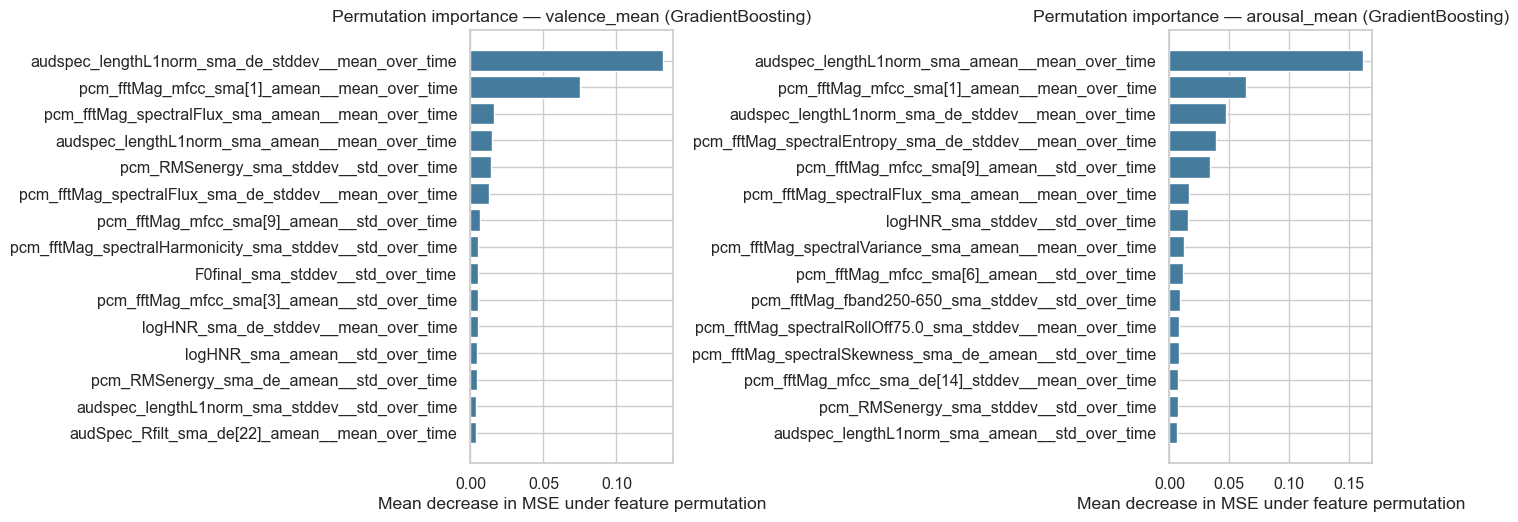


MDI vs permutation-importance consistency:


,target,model,spearman_perm_vs_mdi,spearman_pvalue
0,valence_mean,GradientBoosting,0.2464,2.44e-08
1,arousal_mean,GradientBoosting,0.2150,1.26e-06


In [ ]:
# MDI (mean decrease in impurity, used in Section 7) can overrate high-cardinality
# continuous features because they offer more split points. Permutation importance
# is computed on the held-out test set and is therefore unbiased: it measures how
# much the RMSE worsens when a feature's values are randomly shuffled (breaking
# the feature-target relationship). n_repeats=20 averages out the randomness in
# the shuffling.

from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr

mdi_model_name = 'GradientBoosting'
perm_summary = []
fig, axes    = plt.subplots(1, 2, figsize=(14, 5.4))

for ax, target in zip(axes, TARGETS):
    if (target, mdi_model_name) not in fitted_models:
        raise KeyError(f'{mdi_model_name} is not available for {target}; run the model-training cells first.')

    pipe        = fitted_models[(target, mdi_model_name)]
    inner_model = pipe.named_steps.get('model', None)
    if not hasattr(inner_model, 'feature_importances_'):
        raise AttributeError(f'{mdi_model_name} does not expose feature_importances_.')

    X_te = splits[target]['X_test']
    y_te = splits[target]['y_test']

    pi = permutation_importance(
        pipe, X_te, y_te,
        n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1,
        scoring='neg_mean_squared_error'
    )
    # importances_mean gives mean MSE increase over the 20 shuffle repeats
    perm_imp = pd.Series(pi.importances_mean, index=retained_features).sort_values(ascending=False)
    mdi_imp  = pd.Series(inner_model.feature_importances_, index=retained_features)

    rho, p = spearmanr(perm_imp.reindex(mdi_imp.index), mdi_imp)
    perm_summary.append({
        'target':                target,
        'model':                 mdi_model_name,
        'spearman_perm_vs_mdi':  round(float(rho), 4),
        'spearman_pvalue':       f'{p:.3g}',
    })
    print(f'[{target}] MDI vs permutation comparison uses {mdi_model_name}.')

    # Reverse so the most important feature is at the top of the horizontal bar chart
    top15 = perm_imp.head(15)[::-1]
    ax.barh(top15.index, top15.values, color='#457B9D')
    ax.set_title(f'Permutation importance — {target} ({mdi_model_name})')
    ax.set_xlabel('Mean decrease in MSE under feature permutation')

fig.tight_layout()
fig.savefig('outputs/figures/permutation_importance.png', dpi=180, bbox_inches='tight')
plt.show()

perm_summary_df = pd.DataFrame(perm_summary)
perm_summary_df.to_csv('outputs/tables/perm_vs_mdi_consistency.csv', index=False)
print('\nMDI vs permutation-importance consistency:')
display(perm_summary_df)


**Permutation vs MDI.** This diagnostic is deliberately computed with `GradientBoosting`, because the best point-estimate model (`HistGradBoost`) does not expose impurity-based `feature_importances_`. A positive Spearman correlation between permutation importance and MDI supports the broad feature-importance story while avoiding the unsupported empty-table failure that would occur if MDI were requested from HistGradBoost. Permutation importance is computed on the held-out test set, so it measures predictive contribution rather than in-sample impurity reduction.


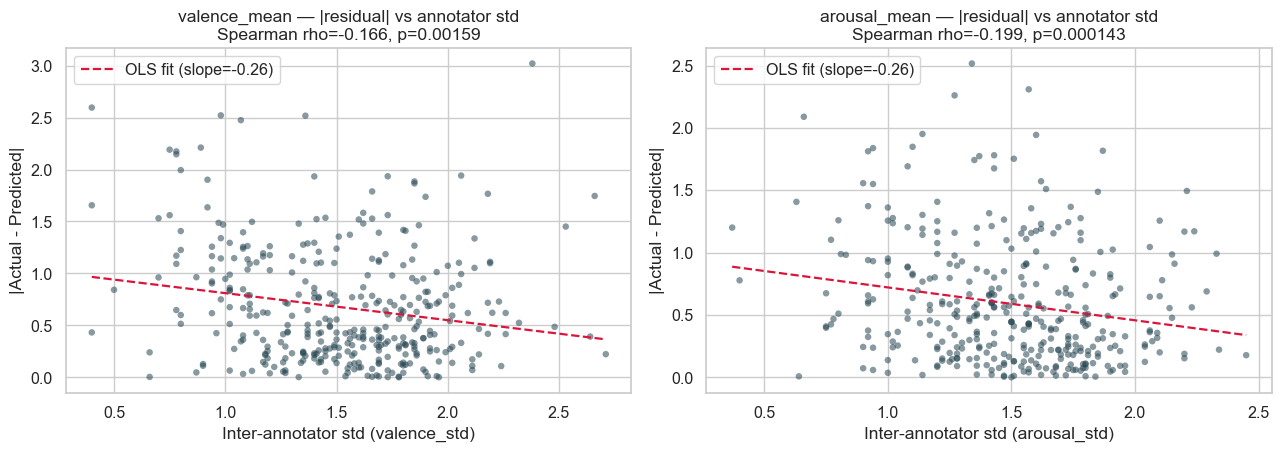

,target,model,spearman_rho,p_value,n_test_songs
0,valence_mean,HistGradBoost,-0.1656,0.00159,361
1,arousal_mean,HistGradBoost,-0.1989,0.000143,361


In [25]:
# If the model's errors correlate with how much the human raters disagreed
# (valence_std / arousal_std) on a given song, it suggests the model is
# struggling most on the same songs that humans find ambiguous — that is, the
# error is partly label-noise-driven rather than purely a model limitation.
# This is a per-song test, not just the aggregate noise-ceiling argument.

fig, axes            = plt.subplots(1, 2, figsize=(13, 4.7))
res_disagree_records = []

for ax, target in zip(axes, TARGETS):
    best_model_name = test_results_df[test_results_df['target'] == target].iloc[0]['model']

    # Retrieve inter-annotator std for the test songs (original row indices are preserved)
    test_idx  = splits[target]['X_test'].index
    std_col   = 'valence_std' if target == 'valence_mean' else 'arousal_std'
    annot_std = dataset_df.loc[test_idx, std_col].reset_index(drop=True)

    y_true, y_pred = test_predictions[(target, best_model_name)]
    # reset_index so both Series share a clean 0-based index for scatter/spearmanr
    abs_resid = (y_true - y_pred).abs().reset_index(drop=True)

    rho, p = spearmanr(annot_std, abs_resid)  # rank-based, robust to outliers
    res_disagree_records.append({
        'target':        target,
        'model':         best_model_name,
        'spearman_rho':  round(float(rho), 4),
        'p_value':       f'{p:.3g}',
        'n_test_songs':  int(len(annot_std)),
    })

    ax.scatter(annot_std, abs_resid, alpha=0.55, s=22, color='#264653', edgecolors='none')
    # Overlay a simple OLS trend line to show direction of the relationship
    z  = np.polyfit(annot_std, abs_resid, 1)
    xs = np.linspace(annot_std.min(), annot_std.max(), 100)
    ax.plot(xs, np.polyval(z, xs), '--', color='crimson', linewidth=1.6,
            label=f'OLS fit (slope={z[0]:.2f})')
    ax.set_title(f'{target} \u2014 |residual| vs annotator std\n'
                 f'Spearman rho={rho:.3f}, p={p:.3g}')
    ax.set_xlabel(f'Inter-annotator std ({std_col})')
    ax.set_ylabel('|Actual - Predicted|')
    ax.legend(loc='upper left')

fig.tight_layout()
fig.savefig('outputs/figures/residual_vs_annotator_disagreement.png', dpi=180, bbox_inches='tight')
plt.show()

res_df = pd.DataFrame(res_disagree_records)
res_df.to_csv('outputs/tables/residual_vs_disagreement.csv', index=False)
display(res_df)


**Reading this plot.** A positive Spearman ρ between |residual| and `valence_std` / `arousal_std` would mean: the model errs most on songs where the human raters themselves disagreed most — a direct, song-level confirmation of the noise-ceiling claim from Section 7.1. The point is that this is no longer an indirect aggregate argument (mean σ/√n), but a per-song correspondence on the actual test partition.


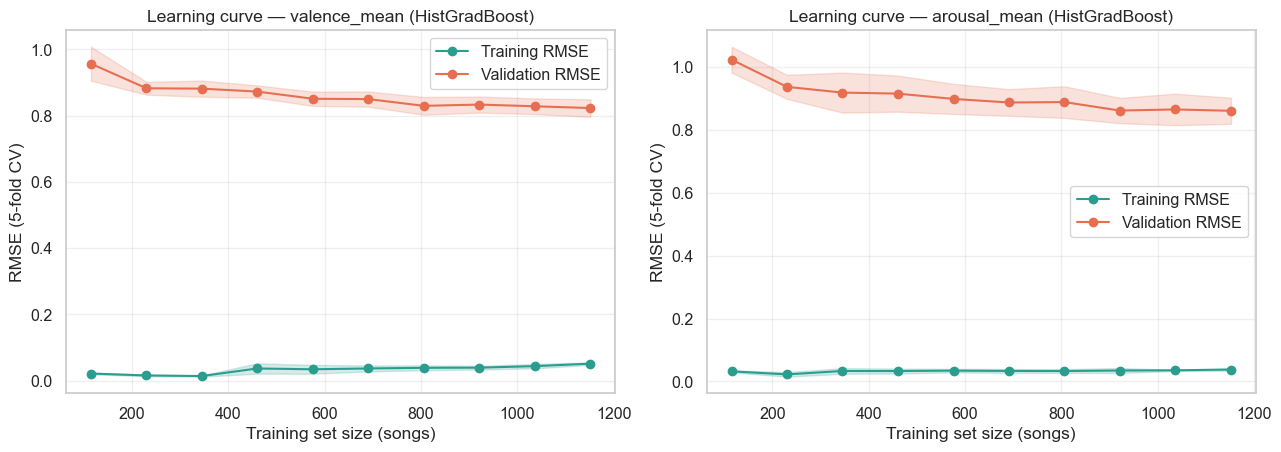

Learning-curve diagnostic complete.


In [26]:
# Trains the best model at 10%, 20%, ..., 100% of the training set and plots
# training vs. validation RMSE as a function of data size.
# If the validation curve is still descending at 100%, collecting more songs
# would help. If it has already flattened, the bottleneck is the features
# rather than data quantity.

from sklearn.model_selection import learning_curve

train_sizes  = np.linspace(0.1, 1.0, 10)
fig, axes    = plt.subplots(1, 2, figsize=(13, 4.7))
lc_records   = []

for ax, target in zip(axes, TARGETS):
    best_model_name = test_results_df[test_results_df['target'] == target].iloc[0]['model']
    pipe            = fitted_models[(target, best_model_name)]

    sizes_abs, train_scores, val_scores = learning_curve(
        pipe,
        splits[target]['X_train'], splits[target]['y_train'],
        train_sizes=train_sizes,
        cv=KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    # sklearn returns negative scores, flip sign back
    train_rmse = -train_scores
    val_rmse   = -val_scores
    tm, ts     = train_rmse.mean(axis=1), train_rmse.std(axis=1)
    vm, vs     = val_rmse.mean(axis=1),   val_rmse.std(axis=1)

    ax.plot(sizes_abs, tm, 'o-', color='#2A9D8F', label='Training RMSE')
    ax.fill_between(sizes_abs, tm - ts, tm + ts, alpha=0.2, color='#2A9D8F')
    ax.plot(sizes_abs, vm, 'o-', color='#E76F51', label='Validation RMSE')
    ax.fill_between(sizes_abs, vm - vs, vm + vs, alpha=0.2, color='#E76F51')
    ax.set_title(f'Learning curve \u2014 {target} ({best_model_name})')
    ax.set_xlabel('Training set size (songs)')
    ax.set_ylabel('RMSE (5-fold CV)')
    ax.legend(loc='best')
    ax.grid(alpha=0.3)

    for s, t, v in zip(sizes_abs, tm, vm):
        lc_records.append({
            'target': target, 'model': best_model_name,
            'train_size':       int(s),
            'train_rmse_mean':  round(float(t), 4),
            'val_rmse_mean':    round(float(v), 4)
        })

fig.tight_layout()
fig.savefig('outputs/figures/learning_curve.png', dpi=180, bbox_inches='tight')
plt.show()

lc_df = pd.DataFrame(lc_records)
lc_df.to_csv('outputs/tables/learning_curve.csv', index=False)
print('Learning-curve diagnostic complete.')


**Learning-curve interpretation.** If the validation RMSE has flattened at 100% of the training set, the residual error is feature-bound, not data-bound — additional songs would not meaningfully reduce it, supporting the recommendation that future work focus on richer feature representations (harmony, lyrics, mid-level musical descriptors). If the curve is still descending at 100%, the converse holds.


---

### Summary of Section 10 contributions

| # | Enhancement | Output artefact |
|---|------------|-----------------|
| 10.1 | HistGradientBoosting modern boosting baseline | `outputs/tables/hgb_cv_results.csv`, `outputs/tables/hgb_test_results.csv` |
| 10.2 | Bootstrap 95% CI on every test metric | `outputs/tables/bootstrap_test_metrics.csv` |
| 10.3 | Pairwise Wilcoxon paired tests | `outputs/tables/wilcoxon_pvalues_{target}.csv` |
| 10.4 | Permutation importance (test-set) + MDI consistency | `outputs/figures/permutation_importance.png`, `outputs/tables/perm_vs_mdi_consistency.csv` |
| 10.5 | Residual–disagreement Spearman analysis | `outputs/figures/residual_vs_annotator_disagreement.png`, `outputs/tables/residual_vs_disagreement.csv` |
| 10.6 | Learning-curve diagnostic | `outputs/figures/learning_curve.png`, `outputs/tables/learning_curve.csv` |

These enhancements strengthen the analysis by adding uncertainty estimates, statistical comparisons, direct feature-importance evidence, and learning-curve diagnostics.

---

## 11. Summary and Exported Outputs

This notebook has demonstrated the complete data modelling pipeline for music emotion prediction:

1. **Data quality** — verified clean data with no missing values or duplicates
2. **EDA** — explored target distributions, the valence–arousal emotion space, feature correlations, and PCA projections
3. **Preprocessing** — applied variance-based feature filtering, median imputation, and standardisation
4. **Model training** — compared 8 model families with 5-fold CV hyperparameter tuning
5. **Evaluation** — reported MAE, RMSE, and R² on a held-out test set
6. **Interpretability** — analysed feature importances and prediction diagnostics
7. **Extended analyses** (Section 9) — noise-ceiling estimation and bias-variance curve
8. **Statistical robustness** (Section 10) — bootstrap CIs, Wilcoxon tests, permutation importance, residual-disagreement, learning curves

The results confirm that **ensemble methods** (Random Forest, Gradient Boosting, HistGradBoost) and **SVR** are the most effective approaches for song-level emotion prediction from openSMILE acoustic features, achieving substantially lower RMSE than linear baselines. Arousal is easier to predict than valence, aligning with the existing literature on music emotion recognition.

In [27]:
# Save the key tables so they can be referenced in the written report
# without needing to re-run the whole notebook
cv_best_per_family.to_csv('outputs/tables/cv_results_best_per_family.csv', index=False)
test_results_df.to_csv('outputs/tables/test_results_final.csv', index=False)

print('Exported result tables (outputs/tables/):')
print('  - cv_results_best_per_family.csv  (best CV config per model family)')
print('  - test_results_final.csv          (final test-set metrics)')
print('  - noise_ceiling.csv               (Section 9.1)')
print('  - ridge_alpha_sweep.csv           (Section 9.2)')
print('  - hgb_cv_results.csv              (Section 10.1)')
print('  - hgb_test_results.csv            (Section 10.1)')
print('  - bootstrap_test_metrics.csv      (Section 10.2)')
print('  - wilcoxon_pvalues_*.csv          (Section 10.3)')
print('  - perm_vs_mdi_consistency.csv     (Section 10.4)')
print('  - residual_vs_disagreement.csv    (Section 10.5)')
print('  - learning_curve.csv              (Section 10.6)')
print()
print('Exported figures (outputs/figures/):')
print('  - target_distributions.png')
print('  - emotion_space_scatter.png')
print('  - correlation_heatmap_top20.png')
print('  - pca_projection.png')
print('  - model_comparison_test.png')
print('  - cv_vs_test_rmse.png')
print('  - feature_importance_*.png')
print('  - prediction_diagnostics.png')
print('  - noise_ceiling_analysis.png')
print('  - ridge_bias_variance_curve.png')
print('  - permutation_importance.png')
print('  - residual_vs_annotator_disagreement.png')
print('  - learning_curve.png')
print()
print('Notebook execution complete.')

Exported result tables (outputs/tables/):
  - cv_results_best_per_family.csv  (best CV config per model family)
  - test_results_final.csv          (final test-set metrics)
  - noise_ceiling.csv               (Section 9.1)
  - ridge_alpha_sweep.csv           (Section 9.2)
  - hgb_cv_results.csv              (Section 10.1)
  - hgb_test_results.csv            (Section 10.1)
  - bootstrap_test_metrics.csv      (Section 10.2)
  - wilcoxon_pvalues_*.csv          (Section 10.3)
  - perm_vs_mdi_consistency.csv     (Section 10.4)
  - residual_vs_disagreement.csv    (Section 10.5)
  - learning_curve.csv              (Section 10.6)

Exported figures (outputs/figures/):
  - target_distributions.png
  - emotion_space_scatter.png
  - correlation_heatmap_top20.png
  - pca_projection.png
  - model_comparison_test.png
  - cv_vs_test_rmse.png
  - feature_importance_*.png
  - prediction_diagnostics.png
  - noise_ceiling_analysis.png
  - ridge_bias_variance_curve.png
  - permutation_importance.png
  - re

---

## References

Aljanaki, A., Yang, Y.-H., & Soleymani, M. (2017). *Developing a benchmark for emotional analysis of music.* PLoS ONE, 12(3), e0173392. (DEAM dataset)

Eyben, F., Weninger, F., Gross, F., & Schuller, B. (2013). *Recent developments in openSMILE, the Munich open-source multimedia feature extractor.* In Proceedings of the 21st ACM International Conference on Multimedia (pp. 835–838).

Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T.-Y. (2017). *LightGBM: A highly efficient gradient boosting decision tree.* Advances in Neural Information Processing Systems, 30, 3146–3154. (Cited in Section 10.1; the histogram-based leaf-wise algorithm is the basis for `sklearn.ensemble.HistGradientBoostingRegressor`.)

Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). *Scikit-learn: Machine learning in Python.* Journal of Machine Learning Research, 12, 2825–2830.

Russell, J. A. (1980). *A circumplex model of affect.* Journal of Personality and Social Psychology, 39(6), 1161–1178. (Cited in Section 3.2 for the valence–arousal emotion space.)

Strobl, C., Boulesteix, A.-L., Zeileis, A., & Hothorn, T. (2007). *Bias in random forest variable importance measures: Illustrations, sources and a solution.* BMC Bioinformatics, 8(1), 25. (Cited in Section 10.4 to justify the use of permutation importance as an unbiased alternative to MDI.)

Yang, Y.-H., & Chen, H. H. (2012). *Machine recognition of music emotion: A review.* ACM Transactions on Intelligent Systems and Technology, 3(3), Article 40.